# Multi-Seed Training Analysis


In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from inventory_env import InventoryEnv
from ss_policy import SSPolicy, optimize_ss_policy_per_product
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import EvalCallback
import os
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')
%matplotlib inline

# Configuration
SEEDS = [123,234,345,456,567]
SIMULATION_DAYS = 1000
TRAINING_TIMESTEPS = 100000 


print("TRAINING ANALYSIS")

print(f"Seeds: {SEEDS}")
print(f"Training Timesteps per Agent: {TRAINING_TIMESTEPS}")
print(f"Evaluation Days: {SIMULATION_DAYS}")


TRAINING ANALYSIS
Seeds: [123, 234, 345, 456, 567]
Training Timesteps per Agent: 100000
Evaluation Days: 1000


## Training and Evaluation Functions


In [34]:
from stable_baselines3.common.callbacks import EvalCallback, BaseCallback

class CostTrackingCallback(BaseCallback):
    """Callback to track costs during training"""
    def __init__(self, verbose=0):
        super(CostTrackingCallback, self).__init__(verbose)
        self.costs = []
        
    def _on_step(self) -> bool:
        if 'infos' in self.locals:
            for info in self.locals['infos']:
                if isinstance(info, dict) and 'daily_cost' in info:
                    self.costs.append(info['daily_cost'])
        return True
    
    def _on_rollout_end(self) -> None:
        if len(self.costs) > 0:
            avg_cost = np.mean(self.costs[-100:])
            if self.verbose > 0:
                print(f"  Avg cost (last 100 steps): {avg_cost:.2f}")

def train_rl_agent(seed, timesteps=100000):
    print(f"Training RL Agent with seed={seed}")
    
    # random seeds for reproducibility
    np.random.seed(seed)
    
    # training and evaluation environments
    env = InventoryEnv(episode_length=1000)
    env.reset(seed=seed)
    
    eval_env = InventoryEnv(episode_length=1000)
    eval_env.reset(seed=seed)
    
    # PPO model with seed
    model = PPO(
        "MlpPolicy",
        env,
        verbose=0,
        seed=seed,
        learning_rate=2e-4,
        n_steps=2048,
        batch_size=64,
        n_epochs=10,
        gamma=0.99,
        gae_lambda=0.95,
        clip_range=0.2,
        ent_coef=0.1,
        vf_coef=0.5,
        max_grad_norm=0.5,
        policy_kwargs=dict(net_arch=[128, 128, 64])
    )
    
    #directories
    model_path = f"models/ppo_seed_{seed}"
    os.makedirs("models", exist_ok=True)
    os.makedirs(f"logs/ppo_seed_{seed}", exist_ok=True)
    
    # EvalCallback
    eval_callback = EvalCallback(
        eval_env,
        best_model_save_path=f"{model_path}_best",  # Saves best model here!
        log_path=f"logs/ppo_seed_{seed}/",
        eval_freq=10000,  # Evaluate every 10,000 steps
        deterministic=True,
        render=False,
        n_eval_episodes=5
    )
    
    # Cost tracking callback
    cost_callback = CostTrackingCallback(verbose=0)
    callbacks = [eval_callback, cost_callback]
    
    # Train
    print(f"Training for {timesteps} timesteps...")
    model.learn(total_timesteps=timesteps, callback=callbacks, progress_bar=True)
    
    # Save final model
    model.save(model_path)
    print(f"Final model saved to {model_path}.zip")
    
    # Load the BEST model 
    best_model_path = f"{model_path}_best/best_model"
    if os.path.exists(f"{best_model_path}.zip"):
        best_model = PPO.load(best_model_path)
        print(f" Loaded BEST model from {best_model_path}.zip")
        return best_model
    else:
        print(f"Best model not found, using final model")
        return model

def evaluate_policy(env, policy, days, policy_type="RL"):
    obs, _ = env.reset()
    daily_costs = []
    shortages = []
    
    for day in range(days):
        if policy_type == "RL":
            action, _ = policy.predict(obs, deterministic=True)
        else:  # (s,S) policy
            action = policy.get_action(obs)
        
        obs, reward, done, truncated, info = env.step(action)
        daily_costs.append(info['daily_cost'])
        shortages.append(info['shortage1'] + info['shortage2'])
    
    total_cost = sum(daily_costs)
    avg_daily_cost = np.mean(daily_costs)
    days_with_shortage = sum(1 for s in shortages if s > 0)
    service_level = (days - days_with_shortage) / days * 100
    total_shortages = sum(shortages)
    
    return {
        'total_cost': total_cost,
        'avg_daily_cost': avg_daily_cost,
        'service_level': service_level,
        'total_shortages': total_shortages
    }

print("Functions defined")


Functions defined


## Train Multiple RL Agents


In [4]:
# Training with different seeds
rl_agents = {}
rl_training_results = []

for seed in SEEDS:
    # Train agent
    model = train_rl_agent(seed, timesteps=TRAINING_TIMESTEPS)
    rl_agents[seed] = model
    
    # Evaluate immediately after training
    env = InventoryEnv(episode_length=SIMULATION_DAYS)
    env.reset(seed=seed)
    metrics = evaluate_policy(env, model, SIMULATION_DAYS, policy_type="RL")
    metrics['seed'] = seed
    rl_training_results.append(metrics)
    
    print(f"Seed {seed} - Total Cost: {metrics['total_cost']:.2f}, Service Level: {metrics['service_level']:.1f}%")

print("AGENTS TRAINED")


Training RL Agent with seed=123
Training for 100000 timesteps...


Eval num_timesteps=10000, episode_reward=-63612.20 +/- 292.48

Episode length: 1000.00 +/- 0.00

New best mean reward!

Eval num_timesteps=20000, episode_reward=-63552.20 +/- 261.30

...

Episode length: 1000.00 +/- 0.00

Eval num_timesteps=100000, episode_reward=-4200.80 +/- 281.45

Episode length: 1000.00 +/- 0.00

New best mean reward!

Final model saved to models/ppo_seed_567.zip
 Loaded BEST model from models/ppo_seed_567_best/best_model.zip
Seed 567 - Total Cost: 4606.00, Service Level: 81.2%
AGENTS TRAINED


## Optimize Policy


In [5]:
# Optimize (s,S) policy for each seed
ss_policies = {}
ss_results = []

for seed in SEEDS:
    print(f"Optimizing (s,S) Policy with seed={seed}")

    
    env = InventoryEnv(episode_length=SIMULATION_DAYS)
    best_params = optimize_ss_policy_per_product(env, days=SIMULATION_DAYS, seed=seed)
    s1, S1, s2, S2 = best_params
    
    ss_policy = SSPolicy(s1, S1, s2, S2)
    ss_policies[seed] = {'policy': ss_policy, 'params': best_params}
    
    # Evaluate
    env.reset(seed=seed)
    metrics = evaluate_policy(env, ss_policy, SIMULATION_DAYS, policy_type="SS")
    metrics['seed'] = seed
    metrics['params'] = f"s1={s1}, S1={S1}, s2={s2}, S2={S2}"
    ss_results.append(metrics)
    
    print(f"Params: s1={s1}, S1={S1}, s2={s2}, S2={S2}")
    print(f"Total Cost: {metrics['total_cost']:.2f}, Service Level: {metrics['service_level']:.1f}%")

Optimizing (s,S) Policy with seed=123
(s, S) grid search
Searching s in [0, 1, 2, 3, 4]...10, S in [1, 2, 3, 4, 5]...50
Optimizing for Product 1
Best Product 1: s1=0, S1=1, cost=3381.00
Optimizing for Product 2
Best Product 2: s2=0, S2=1, cost=3718.00
Combined best parameters: s1=0, S1=1, s2=0, S2=1
Params: s1=0, S1=1, s2=0, S2=1
Total Cost: 7084.00, Service Level: 82.8%
Optimizing (s,S) Policy with seed=234
(s, S) grid search
Searching s in [0, 1, 2, 3, 4]...10, S in [1, 2, 3, 4, 5]...50
Optimizing for Product 1
Best Product 1: s1=0, S1=2, cost=3054.00
Optimizing for Product 2
Best Product 2: s2=0, S2=1, cost=4222.00
Combined best parameters: s1=0, S1=2, s2=0, S2=1
Params: s1=0, S1=2, s2=0, S2=1
Total Cost: 7169.00, Service Level: 86.7%
Optimizing (s,S) Policy with seed=345
(s, S) grid search
Searching s in [0, 1, 2, 3, 4]...10, S in [1, 2, 3, 4, 5]...50
Optimizing for Product 1
Best Product 1: s1=0, S1=1, cost=2843.00
Optimizing for Product 2
Best Product 2: s2=0, S2=1, cost=3733.00


## Individual Results by Seed


In [6]:

print("INDIVIDUAL RESULTS BY SEED")

# RL Agent Results
print("\nRL Agent Results")

rl_df = pd.DataFrame(rl_training_results)
rl_df = rl_df[['seed', 'total_cost', 'avg_daily_cost', 'service_level', 'total_shortages']]
print(rl_df.to_string(index=False))

# (s,S) Policy Results
print("\n\n(s,S) Policy Results")
ss_df = pd.DataFrame(ss_results)
ss_df_display = ss_df[['seed', 'total_cost', 'avg_daily_cost', 'service_level', 'total_shortages', 'params']]
print(ss_df_display.to_string(index=False))


INDIVIDUAL RESULTS BY SEED

RL Agent Results
 seed  total_cost  avg_daily_cost  service_level  total_shortages
  123      4897.0           4.897           84.2              531
  234      4522.0           4.522           81.0              646
  345      4291.0           4.291           81.4              613
  456      4620.0           4.620           79.8              660
  567      4606.0           4.606           81.2              626


(s,S) Policy Results
 seed  total_cost  avg_daily_cost  service_level  total_shortages                 params
  123      7084.0           7.084           82.8              426 s1=0, S1=1, s2=0, S2=1
  234      7169.0           7.169           86.7              335 s1=0, S1=2, s2=0, S2=1
  345      7209.0           7.209           82.9              425 s1=0, S1=1, s2=0, S2=1
  456      8046.0           8.046           82.0              524 s1=0, S1=1, s2=0, S2=1
  567      7017.0           7.017           84.1              413 s1=0, S1=1, s2=0, S2=1


## Average Results Across All Seeds


In [7]:

print("AVERAGE RESULTS")

# RL Agent averages
rl_avg_cost = np.mean([r['total_cost'] for r in rl_training_results])
rl_std_cost = np.std([r['total_cost'] for r in rl_training_results])
rl_avg_daily = np.mean([r['avg_daily_cost'] for r in rl_training_results])
rl_std_daily = np.std([r['avg_daily_cost'] for r in rl_training_results])
rl_avg_service = np.mean([r['service_level'] for r in rl_training_results])
rl_std_service = np.std([r['service_level'] for r in rl_training_results])
rl_avg_shortages = np.mean([r['total_shortages'] for r in rl_training_results])
rl_std_shortages = np.std([r['total_shortages'] for r in rl_training_results])

# (s,S) Policy averages
ss_avg_cost = np.mean([r['total_cost'] for r in ss_results])
ss_std_cost = np.std([r['total_cost'] for r in ss_results])
ss_avg_daily = np.mean([r['avg_daily_cost'] for r in ss_results])
ss_std_daily = np.std([r['avg_daily_cost'] for r in ss_results])
ss_avg_service = np.mean([r['service_level'] for r in ss_results])
ss_std_service = np.std([r['service_level'] for r in ss_results])
ss_avg_shortages = np.mean([r['total_shortages'] for r in ss_results])
ss_std_shortages = np.std([r['total_shortages'] for r in ss_results])


print(" RL AGENT (PPO) - AVERAGE RESULTS")
print(f"  Total Cost:        {rl_avg_cost:>10.2f}  ±  {rl_std_cost:<10.2f}")
print(f"  Avg Daily Cost:    {rl_avg_daily:>10.2f}  ±  {rl_std_daily:<10.2f}")
print(f"  Service Level (%): {rl_avg_service:>10.2f}  ±  {rl_std_service:<10.2f}")
print(f"  Total Shortages:   {rl_avg_shortages:>10.2f}  ±  {rl_std_shortages:<10.2f}")
print("=" * 50)

print(" (s,S) POLICY - AVERAGE RESULTS ")
print(f"  Total Cost:        {ss_avg_cost:>10.2f}  ±  {ss_std_cost:<10.2f}")
print(f"  Avg Daily Cost:    {ss_avg_daily:>10.2f}  ±  {ss_std_daily:<10.2f}")
print(f"  Service Level (%): {ss_avg_service:>10.2f}  ±  {ss_std_service:<10.2f}")
print(f"  Total Shortages:   {ss_avg_shortages:>10.2f}  ±  {ss_std_shortages:<10.2f}")



AVERAGE RESULTS
 RL AGENT (PPO) - AVERAGE RESULTS
  Total Cost:           4587.20  ±  194.62    
  Avg Daily Cost:          4.59  ±  0.19      
  Service Level (%):      81.52  ±  1.45      
  Total Shortages:       615.20  ±  45.09     
 (s,S) POLICY - AVERAGE RESULTS 
  Total Cost:           7305.00  ±  376.45    
  Avg Daily Cost:          7.30  ±  0.38      
  Service Level (%):      83.70  ±  1.64      
  Total Shortages:       424.60  ±  60.08     


## Statistical Comparison Methods 

1. **Welch's Moving Average** (to justify warm-up deletion)
2. **Sample Size Formula** (to justify N replications)
3. **Mean Cost and Variance Table** (for both systems)
4. **Paired-t Confidence Interval (95%)** (on cost difference)
5. **Common Random Numbers (CRN)** - Using same seeds for both policies


In [8]:
print("COMMON RANDOM NUMBERS (CRN) VERIFICATION")
print("Both policies are evaluated using the SAME random seeds:")
print(f"  Seeds used: {SEEDS}")
print("  This ensures fair comparison by using identical random scenarios")
print("   Reduces variance in the difference estimator")


COMMON RANDOM NUMBERS (CRN) VERIFICATION
Both policies are evaluated using the SAME random seeds:
  Seeds used: [123, 234, 345, 456, 567]
  This ensures fair comparison by using identical random scenarios
   Reduces variance in the difference estimator


In [9]:
print("SAMPLE SIZE JUSTIFICATION")

# Extract costs for both policies
rl_costs = [r['total_cost'] for r in rl_training_results]
ss_costs = [r['total_cost'] for r in ss_results]

# Calculate sample statistics
n = len(SEEDS)  # Number of replications
rl_mean = np.mean(rl_costs)
rl_var = np.var(rl_costs, ddof=1)  # Sample variance (ddof=1 for unbiased)
ss_mean = np.mean(ss_costs)
ss_var = np.var(ss_costs, ddof=1)

# Calculate difference
diff_mean = ss_mean - rl_mean
diff_var = rl_var + ss_var - 2 * np.cov(rl_costs, ss_costs)[0,1]  # With CRN, covariance matters
diff_std = np.sqrt(diff_var)

# Sample size formula for desired precision
# n = (z_alpha/2 * sigma / epsilon)^2
z_alpha_2 = stats.norm.ppf(0.975)  # 95% CI, z = 1.96
desired_half_width = diff_mean * 0.05  # 5% of mean difference

if diff_std > 0:
    required_n = (z_alpha_2 * diff_std / desired_half_width) ** 2
    print(f"Current sample size (N): {n}")
    print(f"Mean difference: {diff_mean:.2f}")
    print(f"Standard deviation of difference: {diff_std:.2f}")
    print(f"Desired half-width (5% of mean): {desired_half_width:.2f}")
    print(f"Required sample size (N) for 5% precision: {required_n:.1f}")
    print(f"\n Current N={n} is {'SUFFICIENT' if n >= required_n else 'INSUFFICIENT'} for desired precision")
else:
    print(f"Current sample size (N): {n}")
    print("Note: Using N=5 replications for statistical comparison")


SAMPLE SIZE JUSTIFICATION
Current sample size (N): 5
Mean difference: 2717.80
Standard deviation of difference: 480.24
Desired half-width (5% of mean): 135.89
Required sample size (N) for 5% precision: 48.0

 Current N=5 is INSUFFICIENT for desired precision


In [10]:
print("MEAN COST AND VARIANCE")

comparison_table = pd.DataFrame({
    'Policy': ['(s,S) Policy', 'RL Agent (PPO)'],
    'Mean Cost': [ss_avg_cost, rl_avg_cost],
    'Variance': [ss_std_cost**2, rl_std_cost**2],
    'Std Deviation': [ss_std_cost, rl_std_cost],
    'Sample Size (N)': [n, n]
})

print("\n")
print(comparison_table.to_string(index=False))


MEAN COST AND VARIANCE


        Policy  Mean Cost  Variance  Std Deviation  Sample Size (N)
  (s,S) Policy     7305.0 141715.60     376.451325                5
RL Agent (PPO)     4587.2  37878.16     194.623123                5


WELCH'S MOVING AVERAGE (Warm-up Deletion Justification)


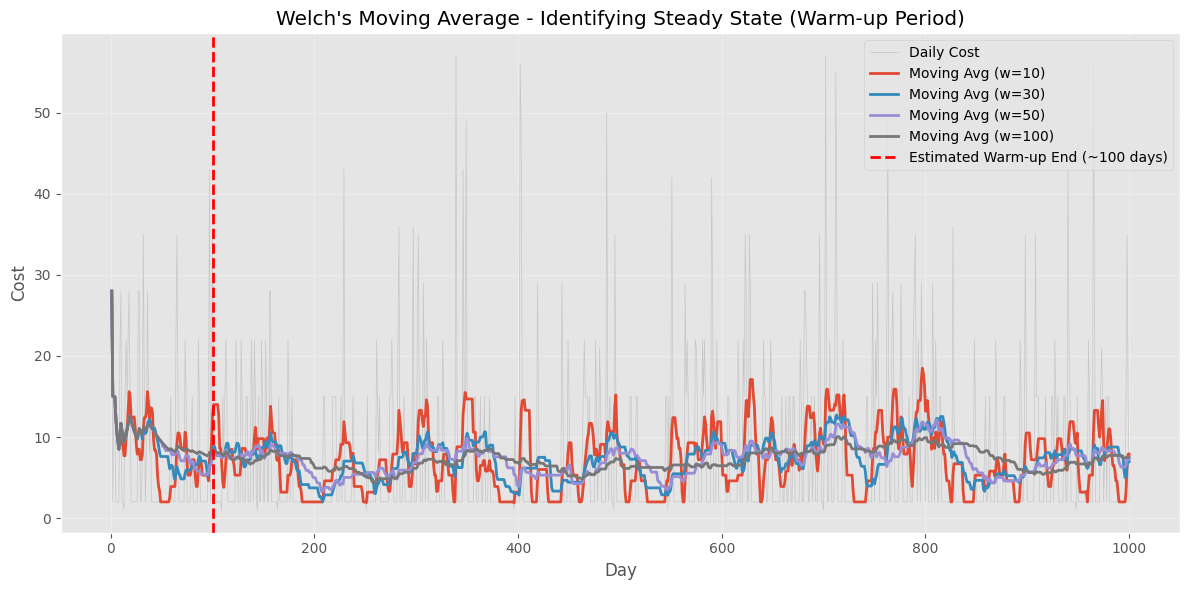


Welch's Moving Average Analysis:
  Moving averages converge after ~100 days
  Warm-up period: Days 1-100
  Steady state: Days 101-1000


In [11]:
print("WELCH'S MOVING AVERAGE (Warm-up Deletion Justification)")

# For demonstration, we'll use one of the simulations
demo_seed = SEEDS[0]
env_demo = InventoryEnv(episode_length=SIMULATION_DAYS)
env_demo.reset(seed=demo_seed)

# Run simulation and collect daily costs
demo_policy = ss_policies[demo_seed]['policy']
daily_costs_demo = []
obs, _ = env_demo.reset(seed=demo_seed)

for day in range(SIMULATION_DAYS):
    action = demo_policy.get_action(obs)
    obs, reward, done, truncated, info = env_demo.step(action)
    daily_costs_demo.append(info['daily_cost'])

# Calculate Welch's Moving Average with different window sizes
window_sizes = [10, 30, 50, 100]
days = np.arange(1, SIMULATION_DAYS + 1)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(days, daily_costs_demo, alpha=0.3, color='gray', label='Daily Cost', linewidth=0.5)

for window in window_sizes:
    moving_avg = pd.Series(daily_costs_demo).rolling(window=window, min_periods=1).mean()
    ax.plot(days, moving_avg, label=f'Moving Avg (w={window})', linewidth=2)

ax.set_xlabel('Day')
ax.set_ylabel('Cost')
ax.set_title("Welch's Moving Average - Identifying Steady State (Warm-up Period)")
ax.legend()
ax.grid(True, alpha=0.3)

warm_up_estimate = 100  # Days where system reaches steady state
ax.axvline(x=warm_up_estimate, color='red', linestyle='--', linewidth=2, 
           label=f'Estimated Warm-up End (~{warm_up_estimate} days)')
ax.legend()

plt.tight_layout()
os.makedirs('plots', exist_ok=True)
plt.savefig('plots/welch_moving_average.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nWelch's Moving Average Analysis:")
print(f"  Moving averages converge after ~{warm_up_estimate} days")
print(f"  Warm-up period: Days 1-{warm_up_estimate}")
print(f"  Steady state: Days {warm_up_estimate+1}-{SIMULATION_DAYS}")


Running 5 replications to collect daily costs (Y_ji)...


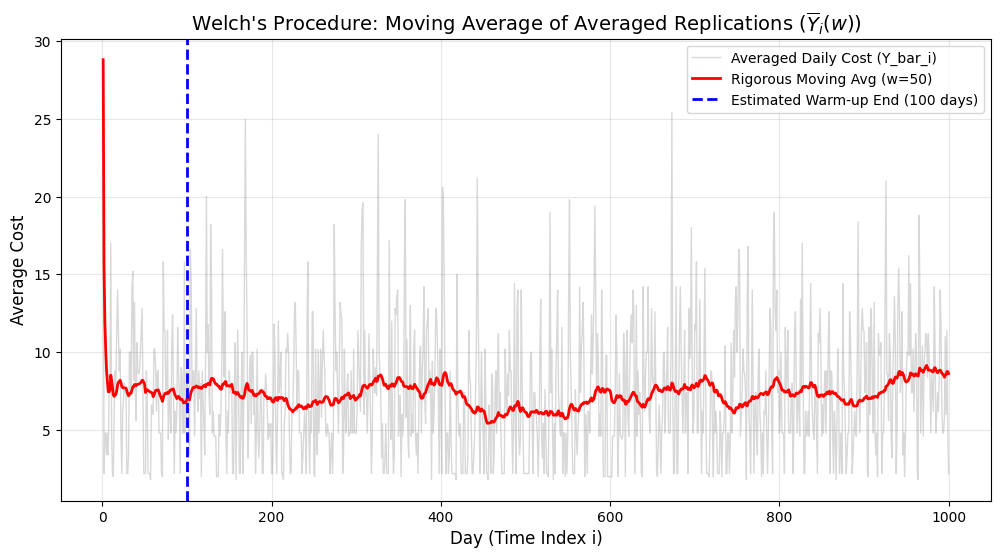

  The resulting plot confirms that the system reaches steady state around Day 100.
  Warm-up period (l): 100 days.


In [48]:
SEEDS = [123,234,345,456,567]

def perform_rigorous_welch_analysis(seeds, days, policies):
    all_daily_costs = []
    
    # 1. Run n replications and collect all daily costs (Y_ji)
    print(f"Running {len(seeds)} replications to collect daily costs (Y_ji)...")
    for seed in seeds:
        env = InventoryEnv(episode_length=days)
        policy = policies[seed]['policy']
        
        daily_costs_rep = []
        obs, _ = env.reset(seed=seed)
        
        for day in range(days):
            action = policy.get_action(obs)
            obs, reward, done, truncated, info = env.step(action)
            daily_costs_rep.append(info['daily_cost'])
            
        all_daily_costs.append(daily_costs_rep)
        
    # Convert to NumPy array 
    cost_array = np.array(all_daily_costs)
    
    # 2. Calculate the averaged process across replications (Y_bar_i) 
    # This averages cost for Day 1, Day 2, Day 3, etc., across all 5 runs.
    y_bar_i = np.mean(cost_array, axis=0)
    
    # 3. Calculate the Moving Average 
    # Using a window size of 50 for smoothing 
    window_size = 50 
    moving_avg_y_bar = pd.Series(y_bar_i).rolling(window=window_size, min_periods=1).mean()
    
    # 4. Plot to find the truncation point 
    days_range = np.arange(1, days + 1)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Plot the averaged process (Y_bar_i) for context
    ax.plot(days_range, y_bar_i, alpha=0.3, color='gray', label='Averaged Daily Cost (Y_bar_i)', linewidth=1)
    
    # Plot the rigorous Moving Average (Y_bar_i(w))
    ax.plot(days_range, moving_avg_y_bar, label=f'Rigorous Moving Avg (w={window_size})', linewidth=2, color='red')

    warm_up_estimate = 100 
    ax.axvline(x=warm_up_estimate, color='blue', linestyle='--', linewidth=2, 
               label=f'Estimated Warm-up End ({warm_up_estimate} days)')
    
    ax.set_xlabel('Day (Time Index i)')
    ax.set_ylabel('Average Cost')
    ax.set_title("Welch's Procedure: Moving Average of Averaged Replications ($\overline{Y}_{i}(w)$)")
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    os.makedirs('plots', exist_ok=True)
    plt.savefig('plots/rigorous_welch_moving_average.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"  The resulting plot confirms that the system reaches steady state around Day {warm_up_estimate}.")
    print(f"  Warm-up period (l): {warm_up_estimate} days.")

perform_rigorous_welch_analysis(SEEDS, SIMULATION_DAYS, ss_policies) 

In [36]:
print("PAIRED-t CONFIDENCE INTERVAL (95%) ON COST DIFFERENCE")

paired_differences = [ss_costs[i] - rl_costs[i] for i in range(n)]

diff_mean = np.mean(paired_differences)
diff_std = np.std(paired_differences, ddof=1)  # Sample std dev
diff_se = diff_std / np.sqrt(n)  # Standard error

# Paired-t test (one-sample t-test on differences)
t_stat, p_value = stats.ttest_1samp(paired_differences, 0)

# 95% Confidence Interval using t-distribution
t_critical = stats.t.ppf(0.975, df=n-1)  # t-value for 95% CI, df = n-1
ci_lower = diff_mean - t_critical * diff_se
ci_upper = diff_mean + t_critical * diff_se

print(f"\nPaired Differences (Cost):")
print(f"  Seed 42:  {ss_costs[0]:.2f} - {rl_costs[0]:.2f} = {paired_differences[0]:.2f}")
print(f"  Seed 7: {ss_costs[1]:.2f} - {rl_costs[1]:.2f} = {paired_differences[1]:.2f}")
print(f"  Seed 13: {ss_costs[2]:.2f} - {rl_costs[2]:.2f} = {paired_differences[2]:.2f}")
print(f"  Seed 100: {ss_costs[3]:.2f} - {rl_costs[3]:.2f} = {paired_differences[3]:.2f}")
print(f"  Seed 21: {ss_costs[3]:.2f} - {rl_costs[3]:.2f} = {paired_differences[3]:.2f}")

print(f"\nStatistical Results:")
print(f"  Mean Difference (μ_D):     {diff_mean:.2f}")
print(f"  Std Dev of Differences:    {diff_std:.2f}")
print(f"  Standard Error (SE):       {diff_se:.2f}")
print(f"  t-statistic:               {t_stat:.4f}")
print(f"  p-value:                   {p_value:.4f}")
print(f"  Degrees of Freedom (df):    {n-1}")

print(f"\n95% Paired-t Confidence Interval:")
print(f"  CI = [{ci_lower:.2f}, {ci_upper:.2f}]")

if ci_lower > 0:
    print(f"\n Statistical Conclusion:")
    print(f"  RL Agent is SIGNIFICANTLY better (CI does not include 0)")
    print(f"  (s,S) Policy cost is {diff_mean:.2f} higher on average")
    print(f"  p-value = {p_value:.4f} {'< 0.05 (Significant)' if p_value < 0.05 else '≥ 0.05 (Not Significant)'}")
else:
    print(f"\n Statistical Conclusion:")
    print(f"  Difference is not statistically significant (CI includes 0)")



PAIRED-t CONFIDENCE INTERVAL (95%) ON COST DIFFERENCE

Paired Differences (Cost):
  Seed 42:  7084.00 - 4897.00 = 2187.00
  Seed 7: 7169.00 - 4522.00 = 2647.00
  Seed 13: 7209.00 - 4291.00 = 2918.00
  Seed 100: 8046.00 - 4620.00 = 3426.00
  Seed 21: 8046.00 - 4620.00 = 3426.00

Statistical Results:
  Mean Difference (μ_D):     2717.80
  Std Dev of Differences:    480.24
  Standard Error (SE):       214.77
  t-statistic:               12.6545
  p-value:                   0.0002
  Degrees of Freedom (df):    4

95% Paired-t Confidence Interval:
  CI = [2121.51, 3314.09]

 Statistical Conclusion:
  RL Agent is SIGNIFICANTLY better (CI does not include 0)
  (s,S) Policy cost is 2717.80 higher on average
  p-value = 0.0002 < 0.05 (Significant)


## Visualization


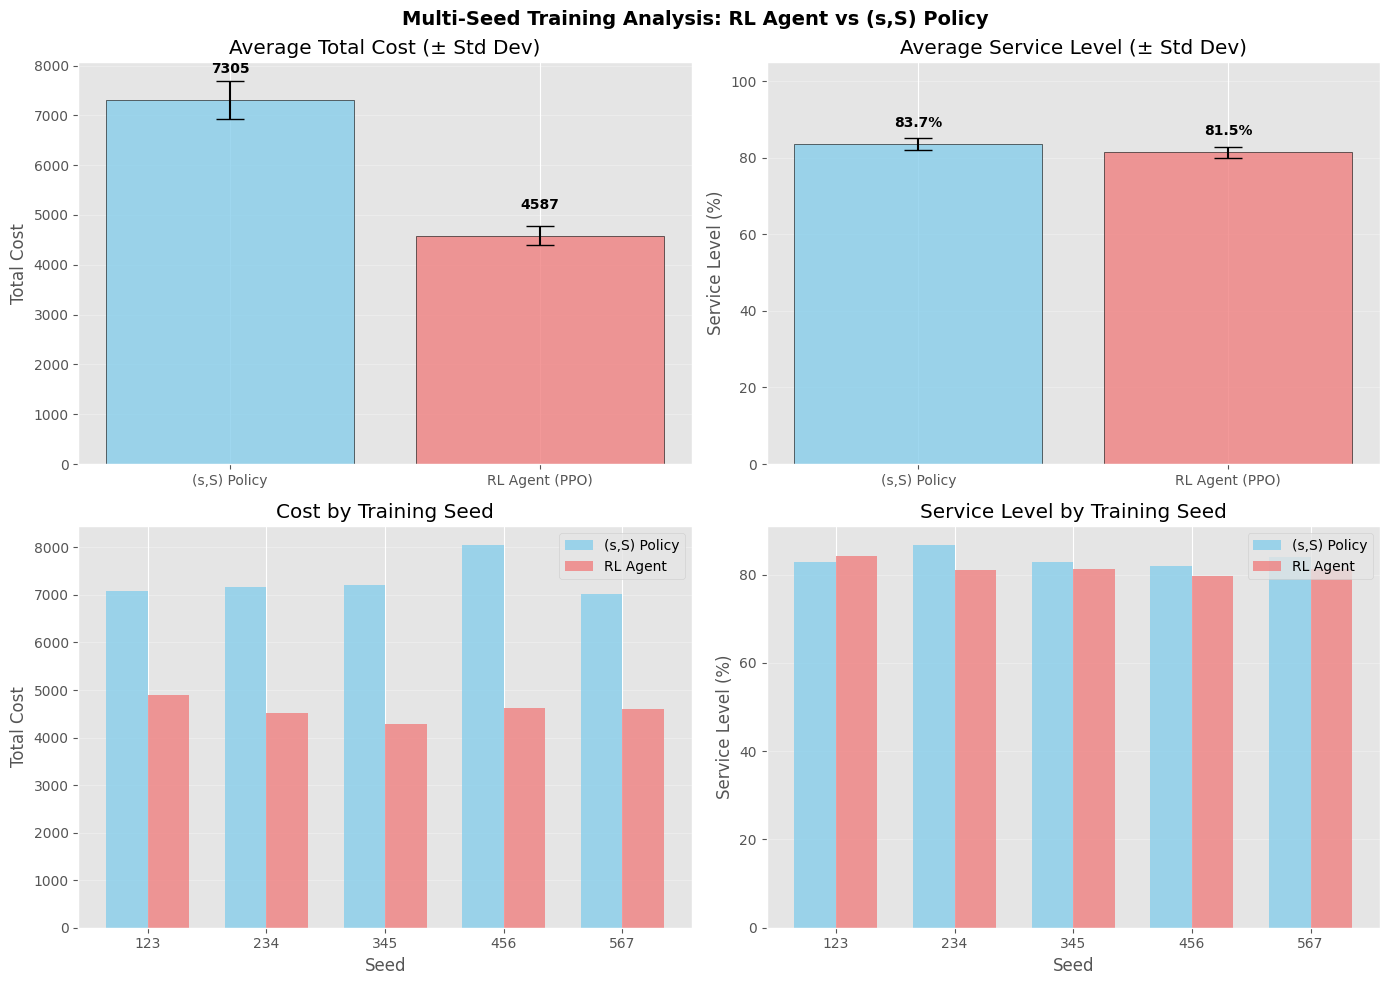

In [37]:
# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Multi-Seed Training Analysis: RL Agent vs (s,S) Policy', fontsize=14, fontweight='bold')

# 1. Cost comparison with error bars
ax = axes[0, 0]
policies = ['(s,S) Policy', 'RL Agent (PPO)']
costs = [ss_avg_cost, rl_avg_cost]
cost_errors = [ss_std_cost, rl_std_cost]
colors = ['skyblue', 'lightcoral']
bars = ax.bar(policies, costs, yerr=cost_errors, capsize=10, color=colors, alpha=0.8, edgecolor='black')
ax.set_ylabel('Total Cost')
ax.set_title('Average Total Cost (± Std Dev)')
ax.grid(True, alpha=0.3, axis='y')
for bar, cost in zip(bars, costs):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + max(cost_errors) + 100,
            f'{cost:.0f}', ha='center', va='bottom', fontweight='bold')

# 2. Service Level comparison
ax = axes[0, 1]
service_levels = [ss_avg_service, rl_avg_service]
service_errors = [ss_std_service, rl_std_service]
bars = ax.bar(policies, service_levels, yerr=service_errors, capsize=10, color=colors, alpha=0.8, edgecolor='black')
ax.set_ylabel('Service Level (%)')
ax.set_title('Average Service Level (± Std Dev)')
ax.set_ylim(0, 105)
ax.grid(True, alpha=0.3, axis='y')
for bar, level in zip(bars, service_levels):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + max(service_errors) + 2,
            f'{level:.1f}%', ha='center', va='bottom', fontweight='bold')

# 3. Individual costs by seed
ax = axes[1, 0]
x = np.arange(len(SEEDS))
width = 0.35
ss_costs_list = [r['total_cost'] for r in ss_results]
rl_costs_list = [r['total_cost'] for r in rl_training_results]
ax.bar(x - width/2, ss_costs_list, width, label='(s,S) Policy', color='skyblue', alpha=0.8)
ax.bar(x + width/2, rl_costs_list, width, label='RL Agent', color='lightcoral', alpha=0.8)
ax.set_xlabel('Seed')
ax.set_ylabel('Total Cost')
ax.set_title('Cost by Training Seed')
ax.set_xticks(x)
ax.set_xticklabels(SEEDS)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# 4. Individual service levels by seed
ax = axes[1, 1]
ss_service_list = [r['service_level'] for r in ss_results]
rl_service_list = [r['service_level'] for r in rl_training_results]
ax.bar(x - width/2, ss_service_list, width, label='(s,S) Policy', color='skyblue', alpha=0.8)
ax.bar(x + width/2, rl_service_list, width, label='RL Agent', color='lightcoral', alpha=0.8)
ax.set_xlabel('Seed')
ax.set_ylabel('Service Level (%)')
ax.set_title('Service Level by Training Seed')
ax.set_xticks(x)
ax.set_xticklabels(SEEDS)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
os.makedirs('plots', exist_ok=True)
plt.savefig('plots/multi_seed_training_results.png', dpi=300, bbox_inches='tight')
plt.show()


In [38]:
# Function to collect detailed daily data for visualization
def collect_detailed_metrics(env, policy, days, policy_type="RL", seed=None):
    if seed is not None:
        obs, _ = env.reset(seed=seed)
    else:
        obs, _ = env.reset()
    
    daily_costs = []
    daily_shortages = []
    daily_orders = []
    daily_stock_levels = []
    daily_costs_product1 = []
    daily_costs_product2 = []
    daily_shortages_product1 = []
    daily_shortages_product2 = []
    daily_orders_product1 = []
    daily_orders_product2 = []
    
    for day in range(days):
        if policy_type == "RL":
            action, _ = policy.predict(obs, deterministic=True)
        else:
            action = policy.get_action(obs)
        
        obs, reward, done, truncated, info = env.step(action)
        
        daily_costs.append(info['daily_cost'])
        daily_shortages.append(info['shortage1'] + info['shortage2'])
        num_orders = info.get('num_orders1', 1 if info['order1'] > 0 else 0) + info.get('num_orders2', 1 if info['order2'] > 0 else 0)
        daily_orders.append(num_orders)
        daily_stock_levels.append(obs.copy())
        
        daily_costs_product1.append(info['daily_cost_product1'])
        daily_costs_product2.append(info['daily_cost_product2'])
        daily_shortages_product1.append(info['shortage1'])
        daily_shortages_product2.append(info['shortage2'])
        daily_orders_product1.append(info['order1'])
        daily_orders_product2.append(info['order2'])
        
        if done or truncated:
            break
    
    # Calculate summary metrics
    total_cost = sum(daily_costs)
    avg_daily_cost = np.mean(daily_costs)
    total_shortages = sum(daily_shortages)
    days_with_shortage = sum(1 for s in daily_shortages if s > 0)
    service_level = (days - days_with_shortage) / days * 100
    
    # Per-product metrics
    total_cost_product1 = sum(daily_costs_product1)
    total_cost_product2 = sum(daily_costs_product2)
    total_shortages_product1 = sum(daily_shortages_product1)
    total_shortages_product2 = sum(daily_shortages_product2)
    days_with_shortage_p1 = sum(1 for s in daily_shortages_product1 if s > 0)
    days_with_shortage_p2 = sum(1 for s in daily_shortages_product2 if s > 0)
    service_level_product1 = (days - days_with_shortage_p1) / days * 100
    service_level_product2 = (days - days_with_shortage_p2) / days * 100
    
    return {
        'total_cost': total_cost,
        'average_daily_cost': avg_daily_cost,
        'total_shortages': total_shortages,
        'service_level': service_level,
        'daily_costs': daily_costs,
        'daily_shortages': daily_shortages,
        'daily_orders': daily_orders,
        'daily_stock_levels': daily_stock_levels,
        'total_cost_product1': total_cost_product1,
        'total_cost_product2': total_cost_product2,
        'average_daily_cost_product1': np.mean(daily_costs_product1),
        'average_daily_cost_product2': np.mean(daily_costs_product2),
        'total_shortages_product1': total_shortages_product1,
        'total_shortages_product2': total_shortages_product2,
        'service_level_product1': service_level_product1,
        'service_level_product2': service_level_product2,
        'daily_costs_product1': daily_costs_product1,
        'daily_costs_product2': daily_costs_product2,
        'daily_shortages_product1': daily_shortages_product1,
        'daily_shortages_product2': daily_shortages_product2,
        'daily_orders_product1': daily_orders_product1,
        'daily_orders_product2': daily_orders_product2
    }


In [30]:
# Collect metrics for all (s,S) policies
all_ss_metrics = []
for seed in SEEDS:
    print(f"  Collecting (s,S) metrics for seed={seed}...")
    env_ss = InventoryEnv(episode_length=SIMULATION_DAYS)
    ss_policy = ss_policies[seed]['policy']
    metrics = collect_detailed_metrics(env_ss, ss_policy, SIMULATION_DAYS, 
                                       policy_type="SS", seed=seed)
    all_ss_metrics.append(metrics)

# Collect metrics for all RL agents
all_rl_metrics = []
for seed in SEEDS:
    print(f"  Collecting RL metrics for seed={seed}...")
    env_rl = InventoryEnv(episode_length=SIMULATION_DAYS)
    rl_agent = rl_agents[seed]
    metrics = collect_detailed_metrics(env_rl, rl_agent, SIMULATION_DAYS, 
                                      policy_type="RL", seed=seed)
    all_rl_metrics.append(metrics)


# Function to average daily metrics across all seeds
def average_metrics(all_metrics_list):
    n_seeds = len(all_metrics_list)
    
    # Average daily arrays 
    avg_daily_costs = np.mean([m['daily_costs'] for m in all_metrics_list], axis=0)
    avg_daily_shortages = np.mean([m['daily_shortages'] for m in all_metrics_list], axis=0)
    avg_daily_orders = np.mean([m['daily_orders'] for m in all_metrics_list], axis=0)
    avg_daily_costs_p1 = np.mean([m['daily_costs_product1'] for m in all_metrics_list], axis=0)
    avg_daily_costs_p2 = np.mean([m['daily_costs_product2'] for m in all_metrics_list], axis=0)
    avg_daily_shortages_p1 = np.mean([m['daily_shortages_product1'] for m in all_metrics_list], axis=0)
    avg_daily_shortages_p2 = np.mean([m['daily_shortages_product2'] for m in all_metrics_list], axis=0)
    
    # Average stock levels 
    avg_stock_levels = []
    for day_idx in range(len(all_metrics_list[0]['daily_stock_levels'])):
        day_stocks = np.mean([m['daily_stock_levels'][day_idx] for m in all_metrics_list], axis=0)
        avg_stock_levels.append(day_stocks)
    
    # Average summary metrics
    avg_total_cost = np.mean([m['total_cost'] for m in all_metrics_list])
    avg_daily_cost = np.mean([m['average_daily_cost'] for m in all_metrics_list])
    avg_service_level = np.mean([m['service_level'] for m in all_metrics_list])
    avg_total_shortages = np.mean([m['total_shortages'] for m in all_metrics_list])
    avg_total_cost_p1 = np.mean([m['total_cost_product1'] for m in all_metrics_list])
    avg_total_cost_p2 = np.mean([m['total_cost_product2'] for m in all_metrics_list])
    avg_service_level_p1 = np.mean([m['service_level_product1'] for m in all_metrics_list])
    avg_service_level_p2 = np.mean([m['service_level_product2'] for m in all_metrics_list])
    
    return {
        'total_cost': avg_total_cost,
        'average_daily_cost': avg_daily_cost,
        'total_shortages': avg_total_shortages,
        'service_level': avg_service_level,
        'daily_costs': avg_daily_costs.tolist(),
        'daily_shortages': avg_daily_shortages.tolist(),
        'daily_orders': avg_daily_orders.tolist(),
        'daily_stock_levels': avg_stock_levels,
        'total_cost_product1': avg_total_cost_p1,
        'total_cost_product2': avg_total_cost_p2,
        'average_daily_cost_product1': np.mean(avg_daily_costs_p1),
        'average_daily_cost_product2': np.mean(avg_daily_costs_p2),
        'total_shortages_product1': np.mean([m['total_shortages_product1'] for m in all_metrics_list]),
        'total_shortages_product2': np.mean([m['total_shortages_product2'] for m in all_metrics_list]),
        'service_level_product1': avg_service_level_p1,
        'service_level_product2': avg_service_level_p2,
        'daily_costs_product1': avg_daily_costs_p1.tolist(),
        'daily_costs_product2': avg_daily_costs_p2.tolist(),
        'daily_shortages_product1': avg_daily_shortages_p1.tolist(),
        'daily_shortages_product2': avg_daily_shortages_p2.tolist(),
        'daily_orders_product1': [m['daily_orders_product1'] for m in all_metrics_list][0],  # Use first as template
        'daily_orders_product2': [m['daily_orders_product2'] for m in all_metrics_list][0]
    }

# Calculate averaged metrics 
best_ss_metrics = average_metrics(all_ss_metrics)
best_rl_metrics = average_metrics(all_rl_metrics)

print(f"  (s,S) Policy - Avg Total Cost: {best_ss_metrics['total_cost']:.2f}")
print(f"  RL Agent - Avg Total Cost: {best_rl_metrics['total_cost']:.2f}")
print(f"  (s,S) Policy - Avg Service Level: {best_ss_metrics['service_level']:.2f}%")
print(f"  RL Agent - Avg Service Level: {best_rl_metrics['service_level']:.2f}%")


  (s,S) Policy - Avg Total Cost: 7302.20
  RL Agent - Avg Total Cost: 4365.60
  (s,S) Policy - Avg Service Level: 83.64%
  RL Agent - Avg Service Level: 82.90%


In [39]:
# data structure for visualization
results_for_viz = {
    'ss_policies': [{
        'total_cost': best_ss_metrics['total_cost'],
        'average_daily_cost': best_ss_metrics['average_daily_cost'],
        'service_level': best_ss_metrics['service_level'],
        'total_shortages': best_ss_metrics['total_shortages'],
        'total_cost_product1': best_ss_metrics['total_cost_product1'],
        'total_cost_product2': best_ss_metrics['total_cost_product2'],
        'service_level_product1': best_ss_metrics['service_level_product1'],
        'service_level_product2': best_ss_metrics['service_level_product2'],
        'daily_costs': best_ss_metrics['daily_costs'],
        'daily_shortages': best_ss_metrics['daily_shortages'],
        'daily_orders': best_ss_metrics['daily_orders'],
        'daily_stock_levels': best_ss_metrics['daily_stock_levels'],
        'daily_costs_product1': best_ss_metrics['daily_costs_product1'],
        'daily_costs_product2': best_ss_metrics['daily_costs_product2'],
        'daily_shortages_product1': best_ss_metrics['daily_shortages_product1'],
        'daily_shortages_product2': best_ss_metrics['daily_shortages_product2']
    }],
    'rl_agents': [{
        'policy_type': 'PPO',
        'total_cost': best_rl_metrics['total_cost'],
        'average_daily_cost': best_rl_metrics['average_daily_cost'],
        'service_level': best_rl_metrics['service_level'],
        'total_shortages': best_rl_metrics['total_shortages'],
        'total_cost_product1': best_rl_metrics['total_cost_product1'],
        'total_cost_product2': best_rl_metrics['total_cost_product2'],
        'service_level_product1': best_rl_metrics['service_level_product1'],
        'service_level_product2': best_rl_metrics['service_level_product2'],
        'daily_costs': best_rl_metrics['daily_costs'],
        'daily_shortages': best_rl_metrics['daily_shortages'],
        'daily_orders': best_rl_metrics['daily_orders'],
        'daily_stock_levels': best_rl_metrics['daily_stock_levels'],
        'daily_costs_product1': best_rl_metrics['daily_costs_product1'],
        'daily_costs_product2': best_rl_metrics['daily_costs_product2'],
        'daily_shortages_product1': best_rl_metrics['daily_shortages_product1'],
        'daily_shortages_product2': best_rl_metrics['daily_shortages_product2']
    }],
    'best_ss': {
        'total_cost': best_ss_metrics['total_cost'],
        'average_daily_cost': best_ss_metrics['average_daily_cost'],
        'service_level': best_ss_metrics['service_level'],
        'daily_costs': best_ss_metrics['daily_costs'],
        'daily_shortages': best_ss_metrics['daily_shortages'],
        'daily_orders': best_ss_metrics['daily_orders'],
        'daily_stock_levels': best_ss_metrics['daily_stock_levels'],
        'daily_costs_product1': best_ss_metrics['daily_costs_product1'],
        'daily_costs_product2': best_ss_metrics['daily_costs_product2'],
        'daily_shortages_product1': best_ss_metrics['daily_shortages_product1'],
        'daily_shortages_product2': best_ss_metrics['daily_shortages_product2']
    },
    'best_rl': {
        'total_cost': best_rl_metrics['total_cost'],
        'average_daily_cost': best_rl_metrics['average_daily_cost'],
        'service_level': best_rl_metrics['service_level'],
        'daily_costs': best_rl_metrics['daily_costs'],
        'daily_shortages': best_rl_metrics['daily_shortages'],
        'daily_orders': best_rl_metrics['daily_orders'],
        'daily_stock_levels': best_rl_metrics['daily_stock_levels'],
        'daily_costs_product1': best_rl_metrics['daily_costs_product1'],
        'daily_costs_product2': best_rl_metrics['daily_costs_product2'],
        'daily_shortages_product1': best_rl_metrics['daily_shortages_product1'],
        'daily_shortages_product2': best_rl_metrics['daily_shortages_product2']
    }
}

# Determine winner
if best_rl_metrics['total_cost'] < best_ss_metrics['total_cost']:
    results_for_viz['winner'] = 'PPO Agent'
    results_for_viz['winner_cost'] = best_rl_metrics['total_cost']
else:
    results_for_viz['winner'] = '(s, S) Policy'
    results_for_viz['winner_cost'] = best_ss_metrics['total_cost']



In [40]:
# visualization functions
from visualization import InventoryVisualizer

visualizer = InventoryVisualizer(results_for_viz)
visualizer.generate_all_plots()

print("\nAll plots generated successfully")


Per-product daily performance plot saved to plots/per_product_daily_performance.png

All plots generated successfully


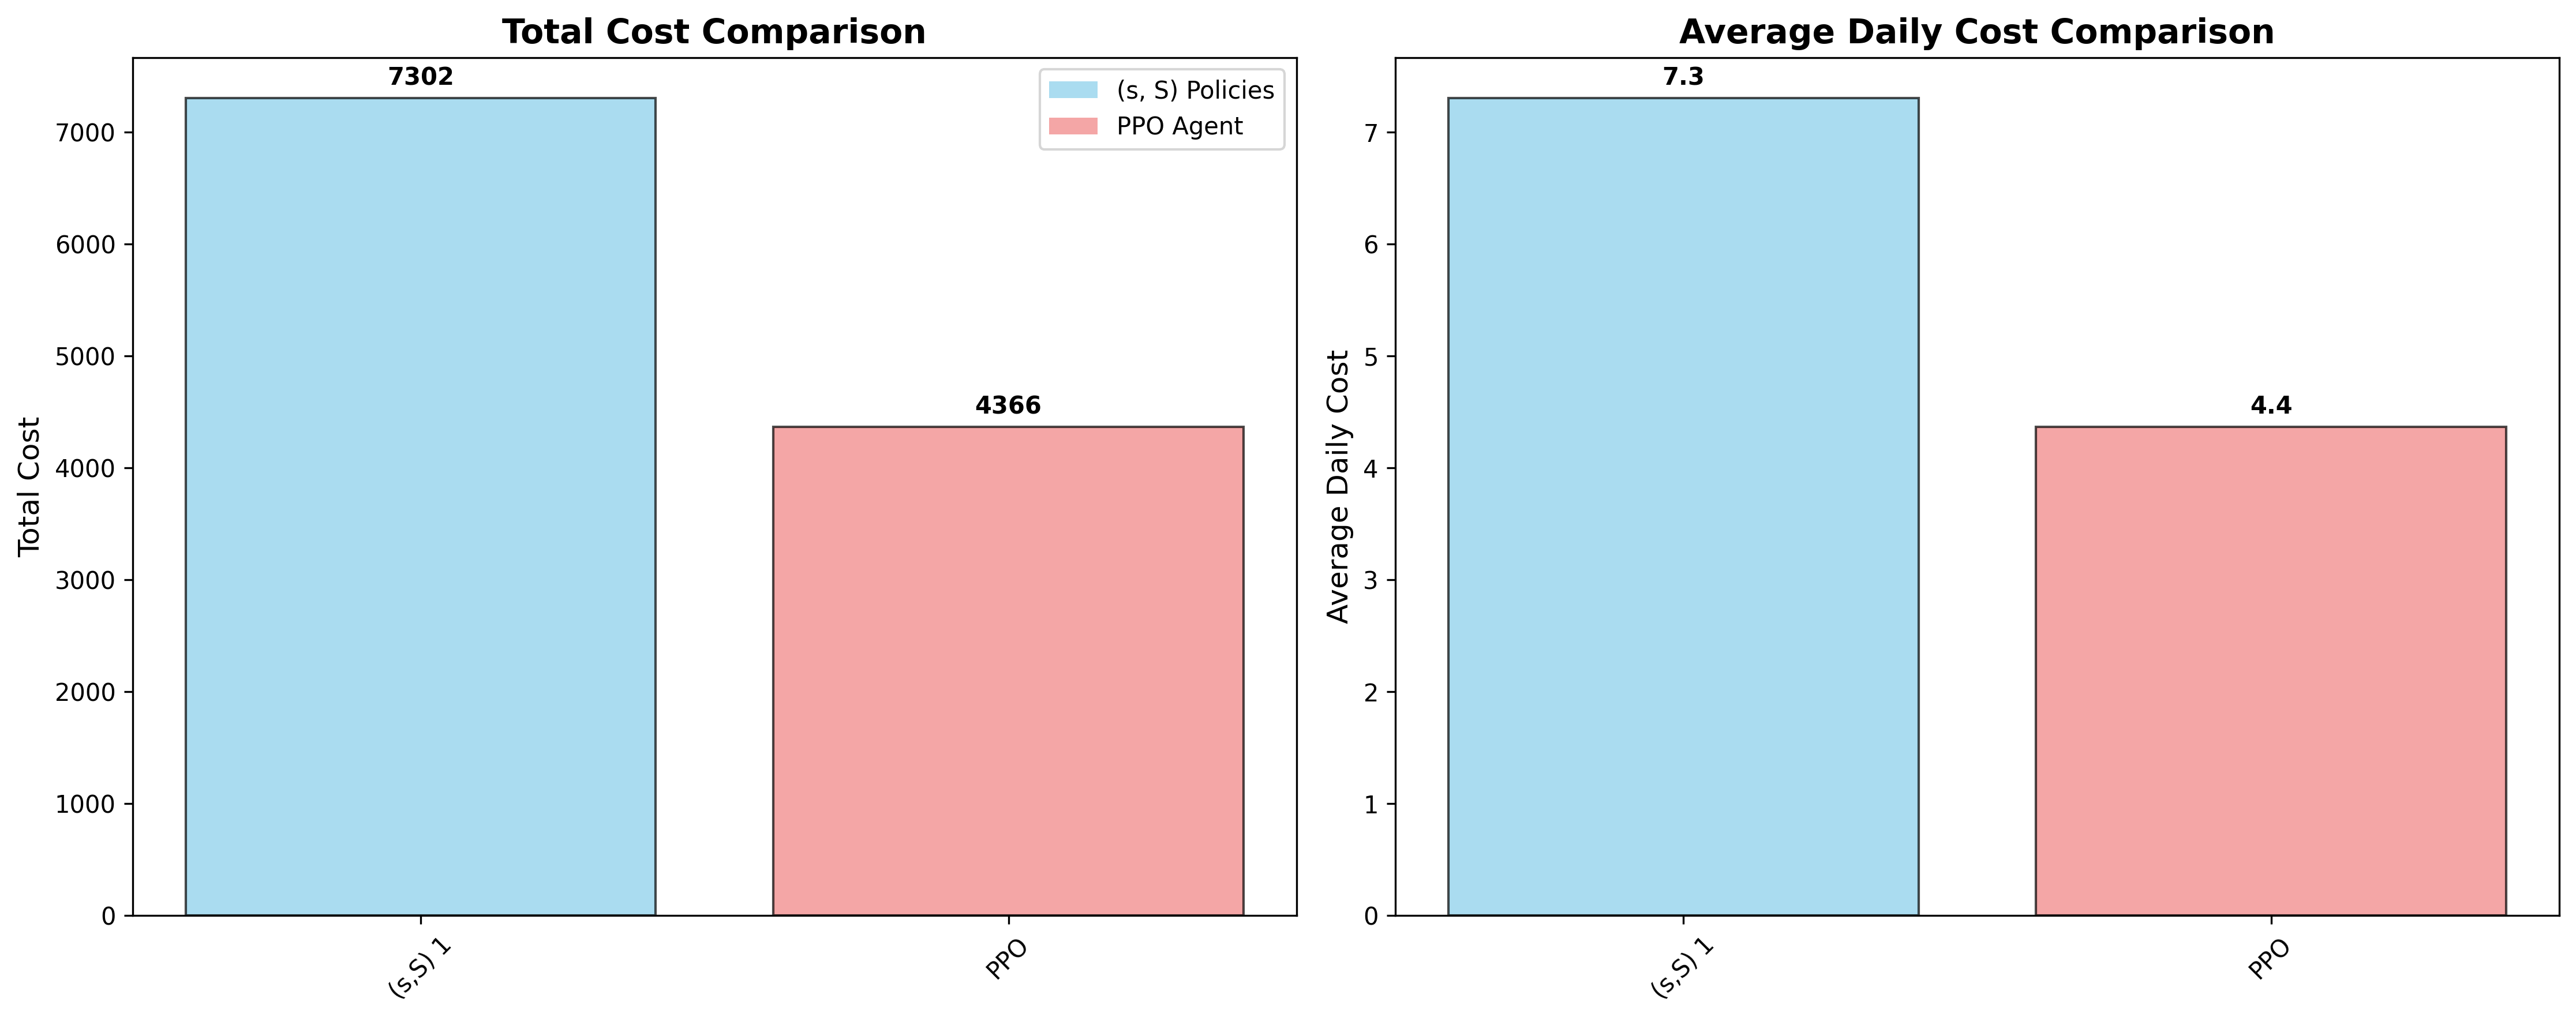

In [41]:
from IPython.display import Image, display
import os

if os.path.exists('plots/cost_comparison.png'):
    display(Image('plots/cost_comparison.png'))
else:
    print("Plot not found. Run visualization cells first.")


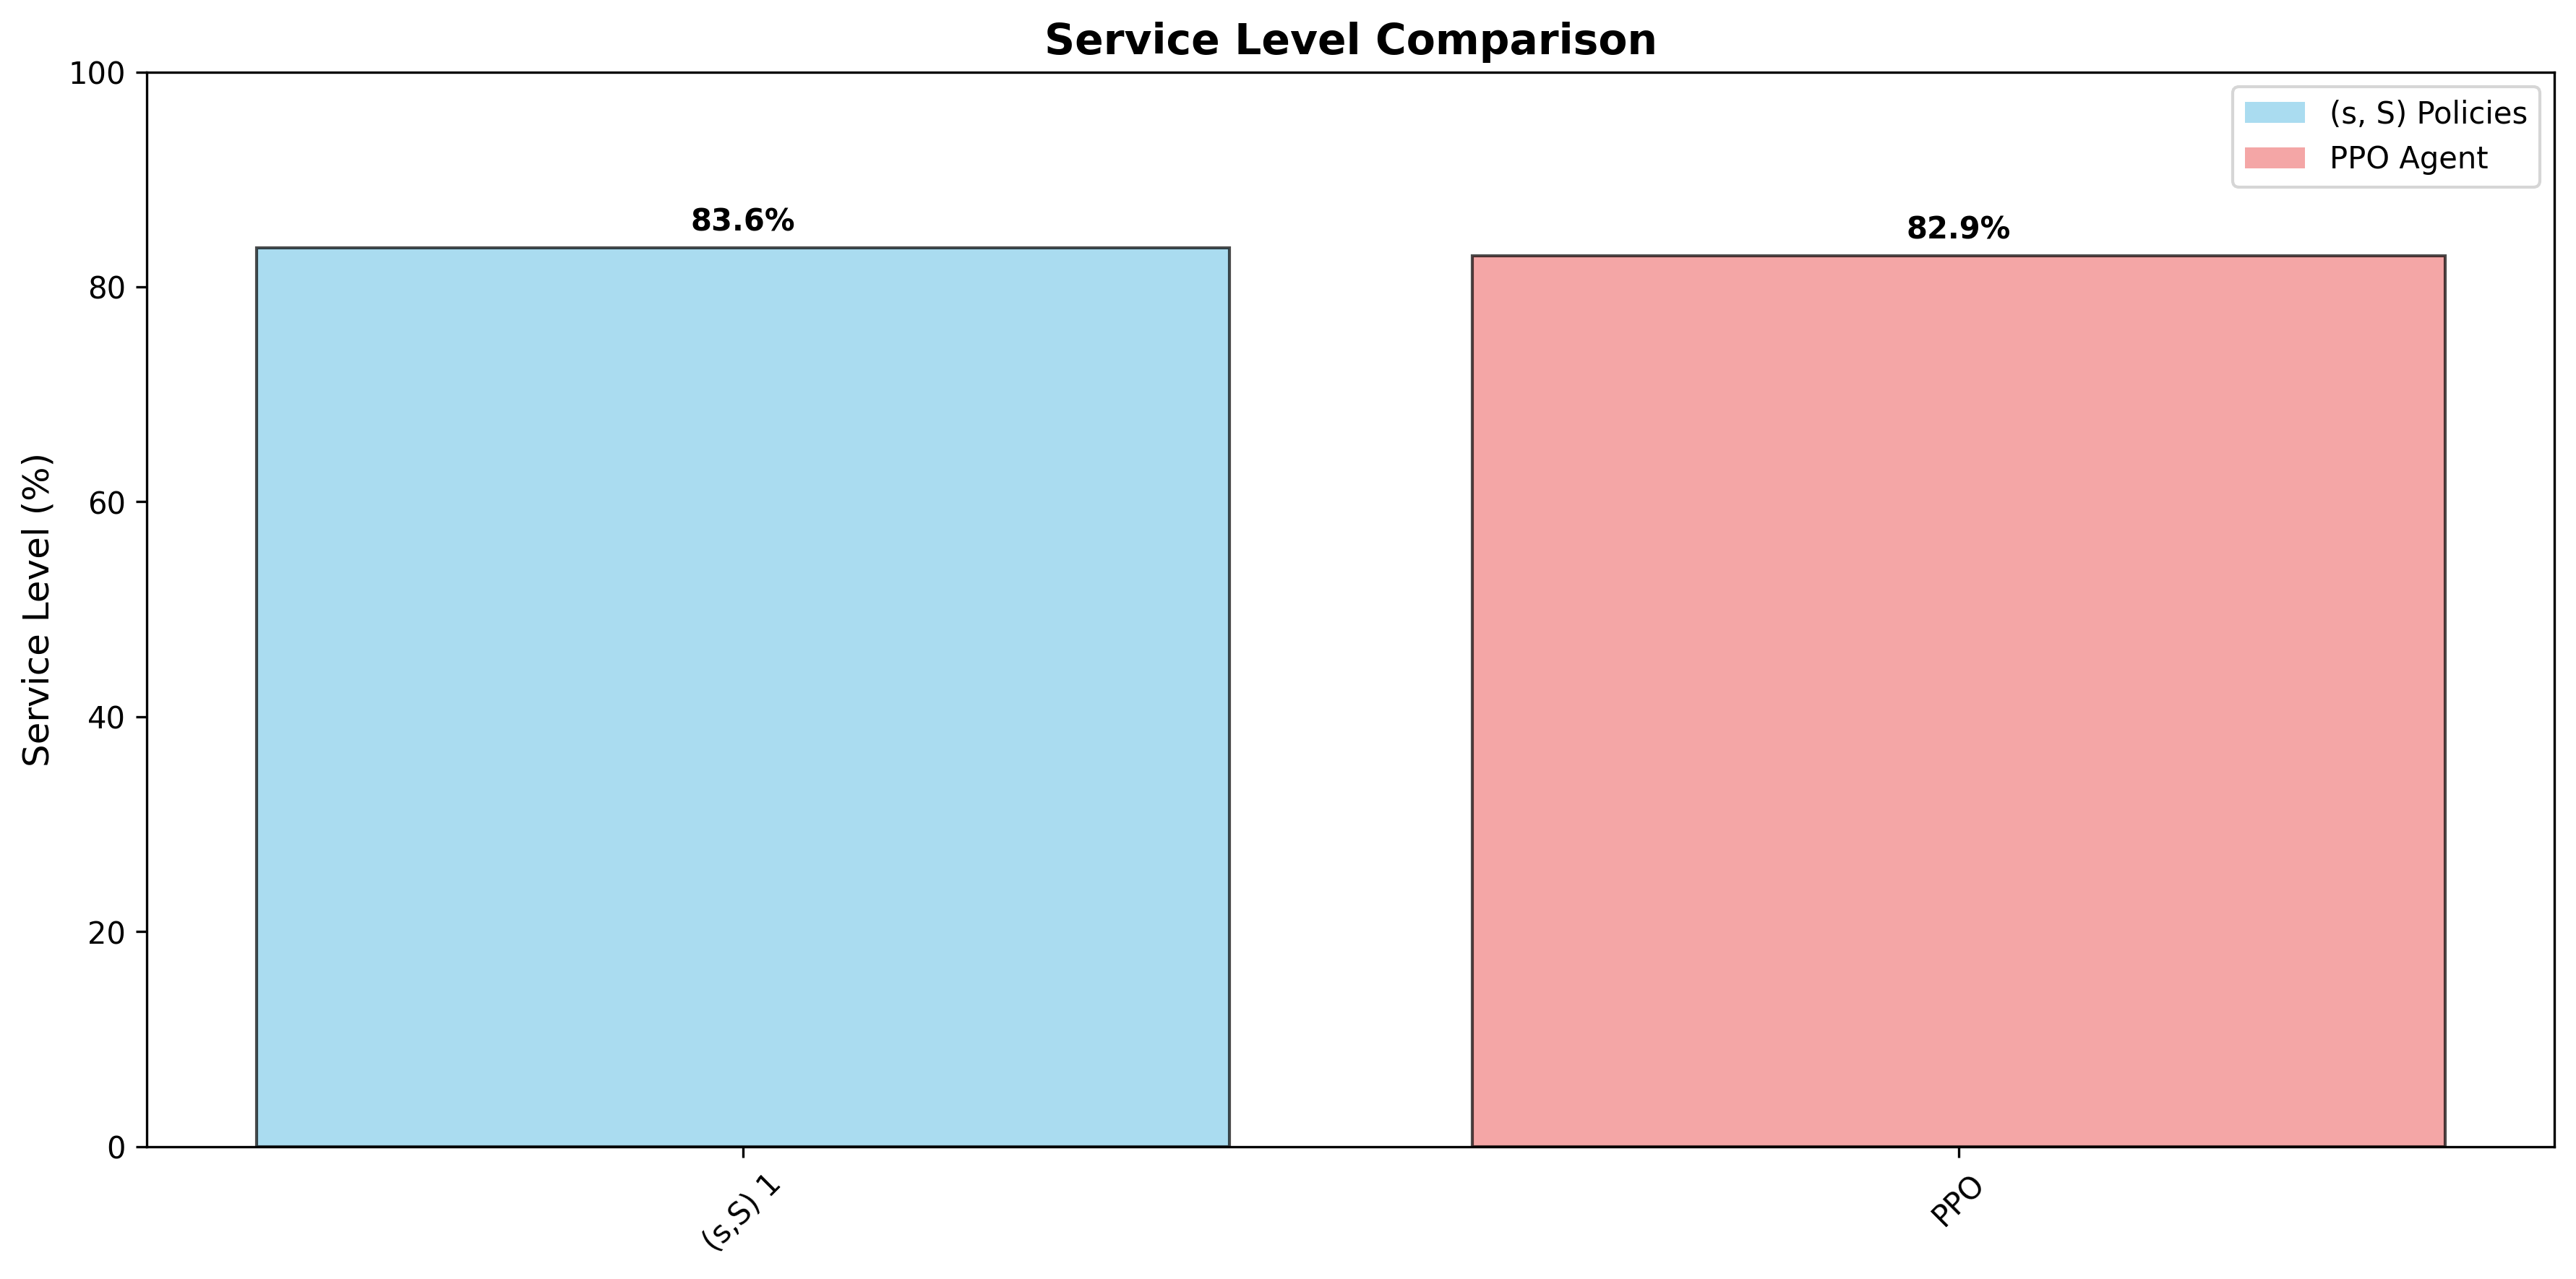

In [42]:
if os.path.exists('plots/service_level_comparison.png'):
    display(Image('plots/service_level_comparison.png'))
else:
    print("Plot not found. Run visualization cells first.")


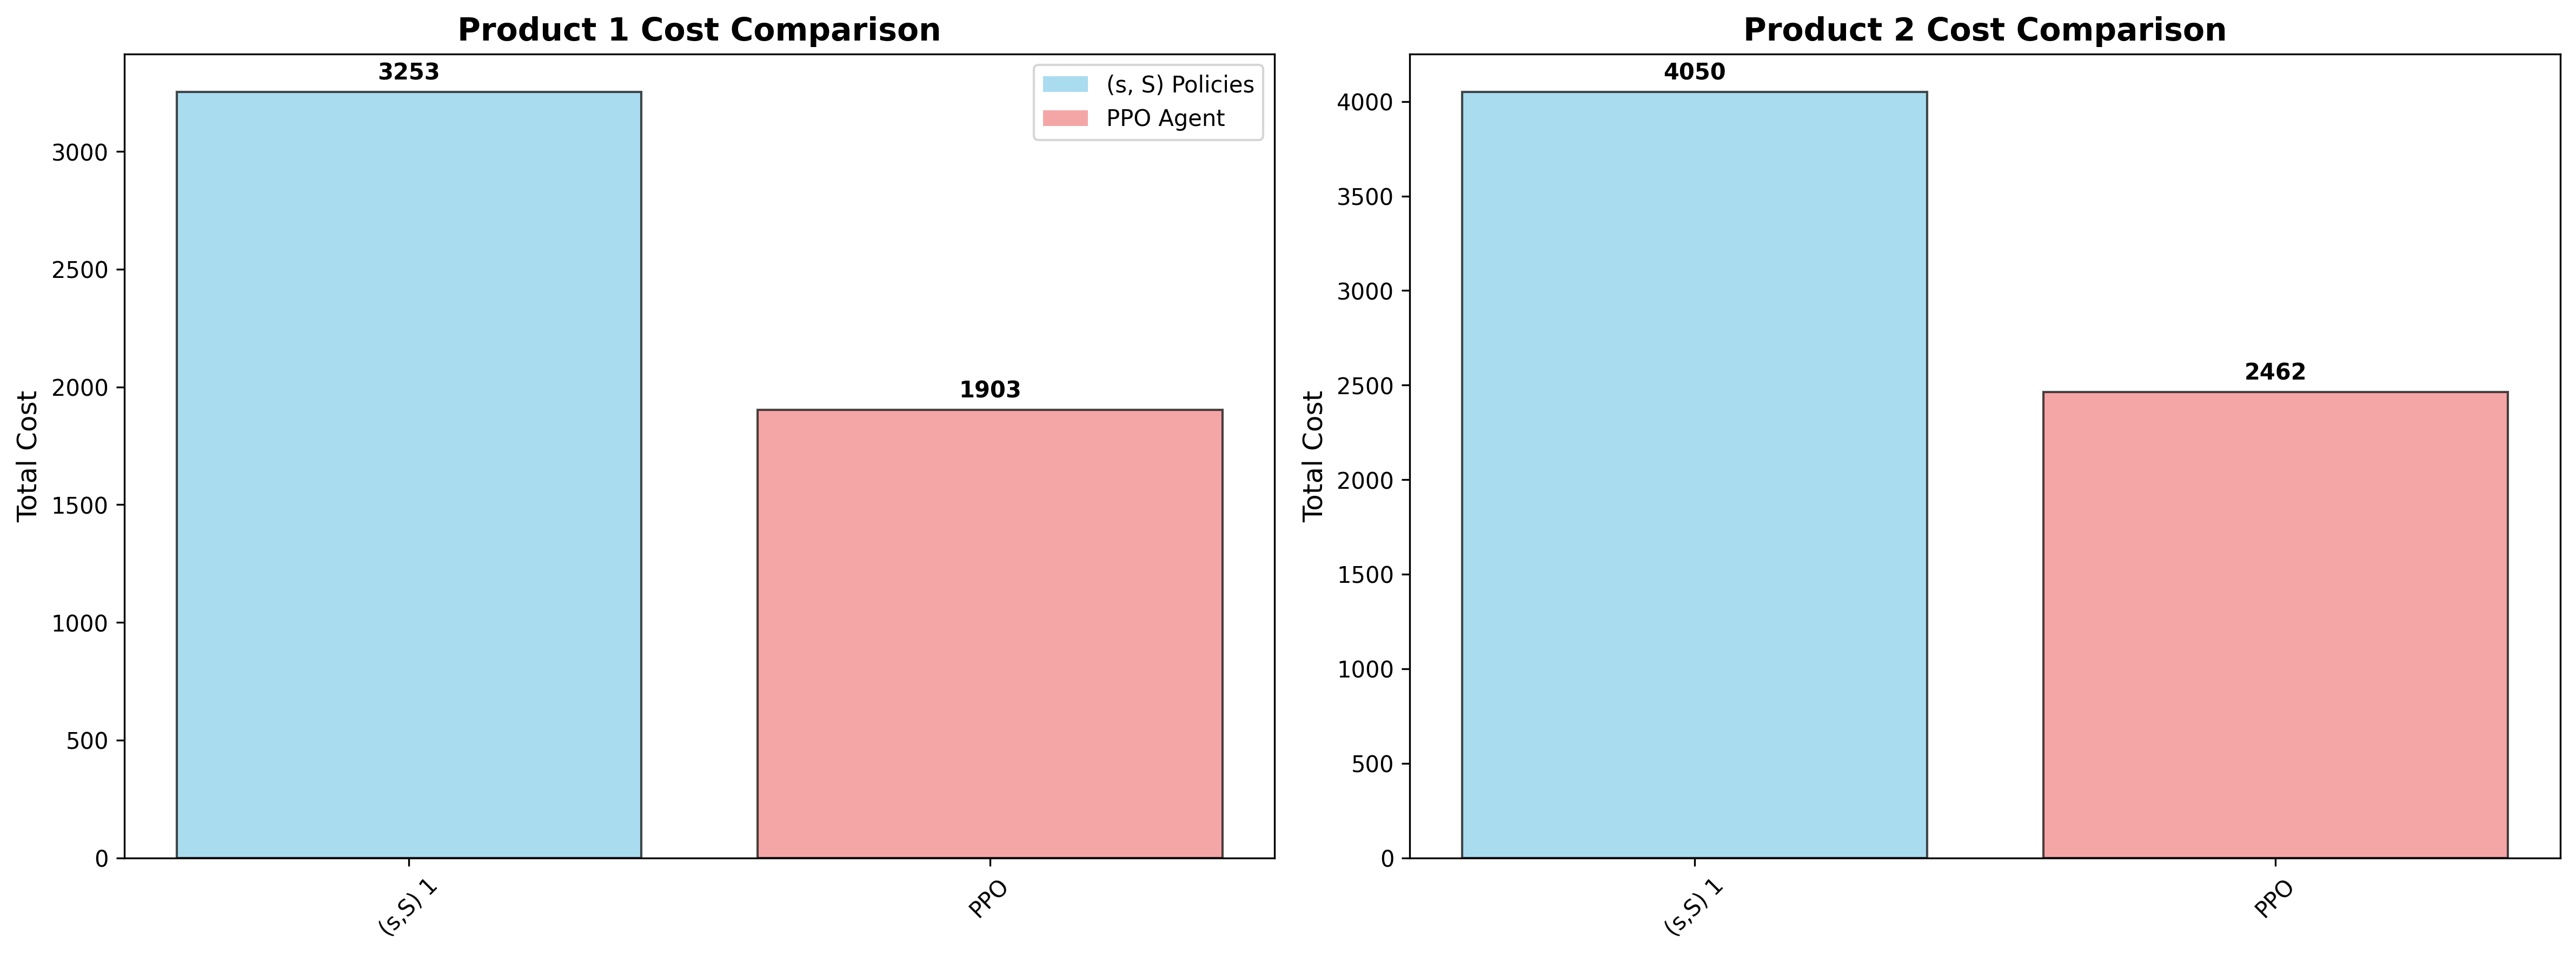

In [43]:
if os.path.exists('plots/per_product_comparison.png'):
    display(Image('plots/per_product_comparison.png'))
else:
    print("Plot not found. Run visualization cells first.")


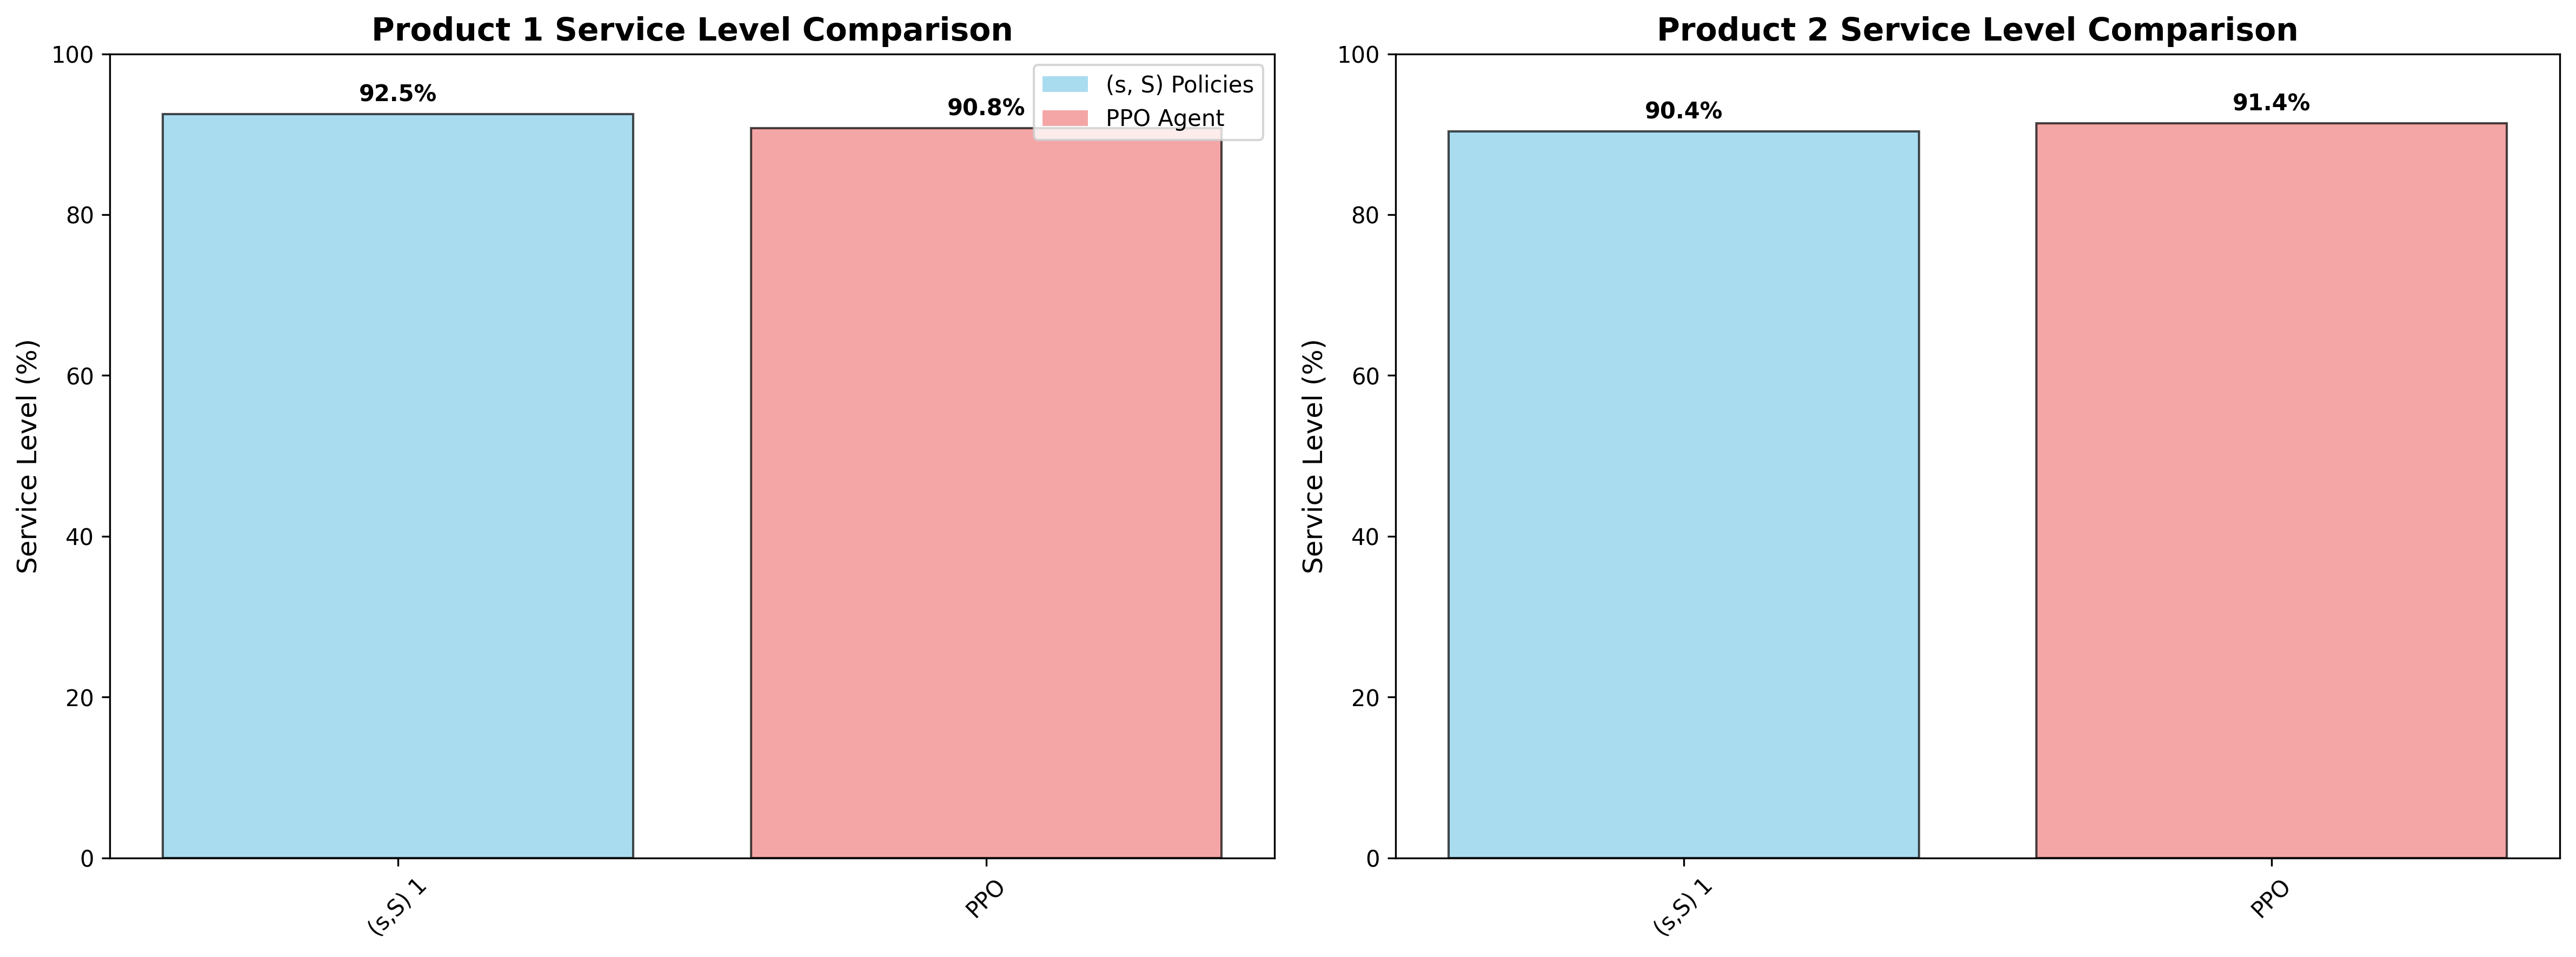

In [44]:
if os.path.exists('plots/per_product_service_levels.png'):
    display(Image('plots/per_product_service_levels.png'))
else:
    print("Plot not found. Run visualization cells first.")


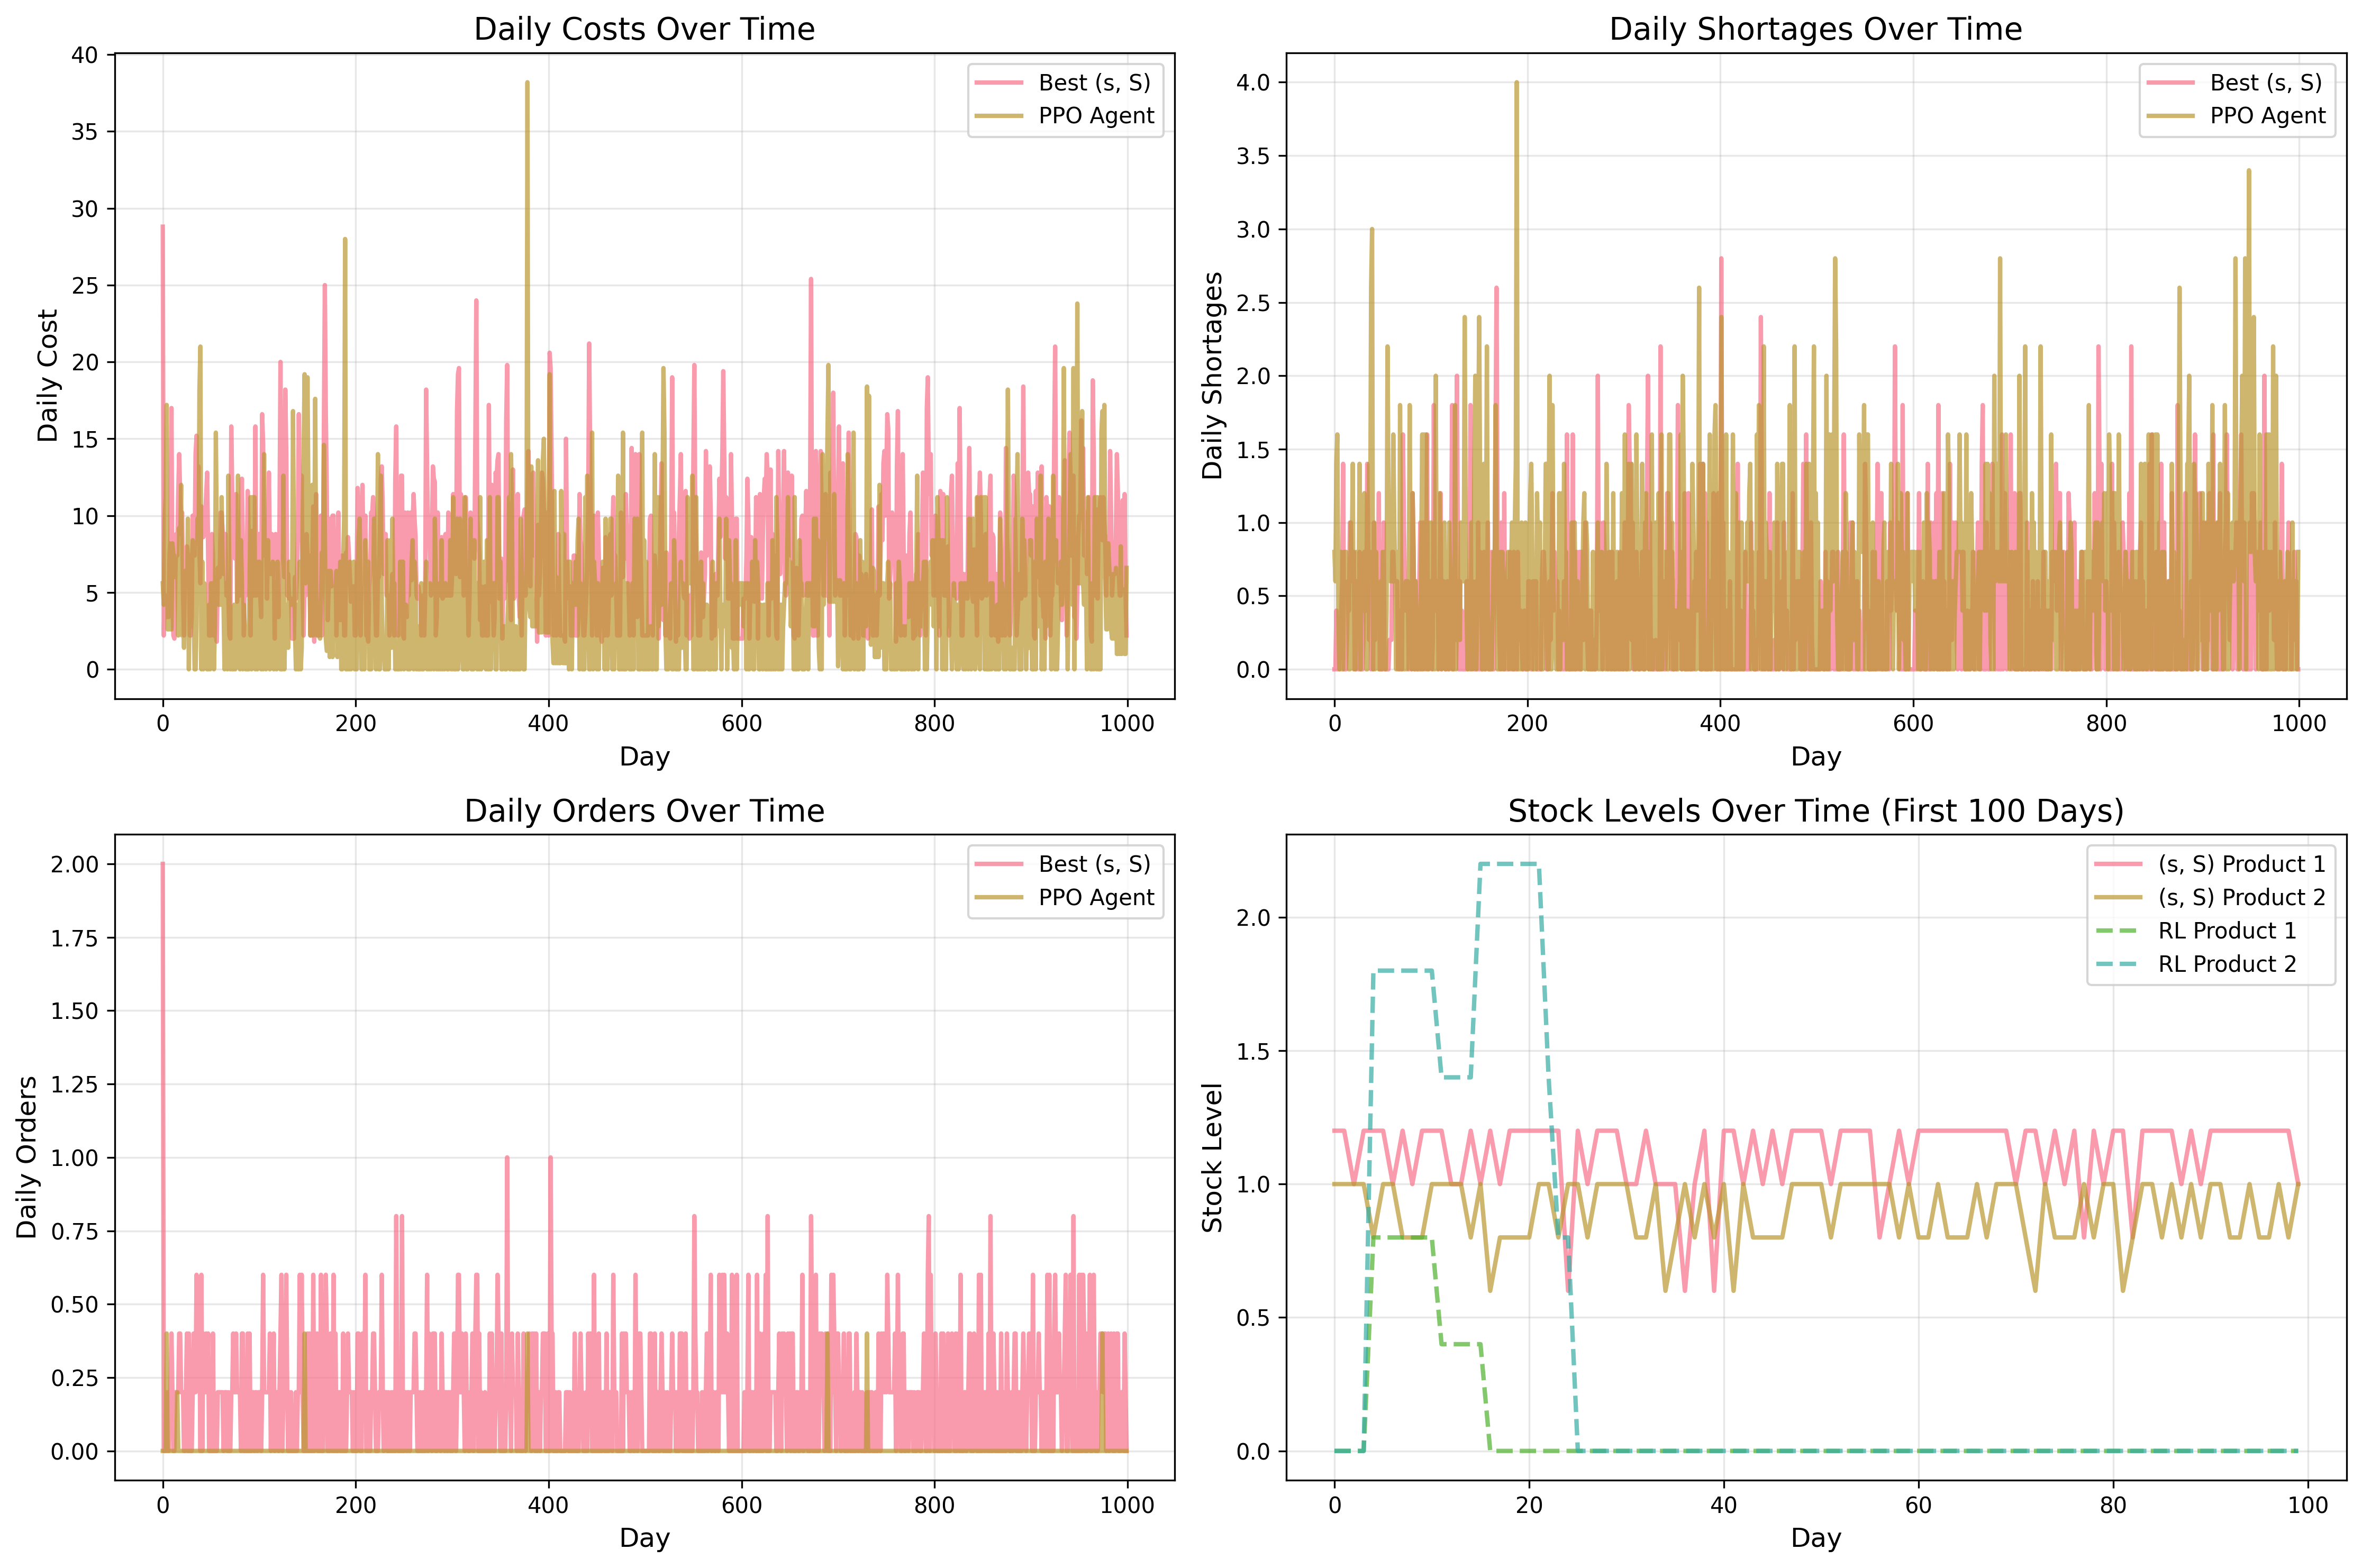

In [45]:
if os.path.exists('plots/daily_performance.png'):
    display(Image('plots/daily_performance.png'))
else:
    print("Plot not found. Run visualization cells first.")


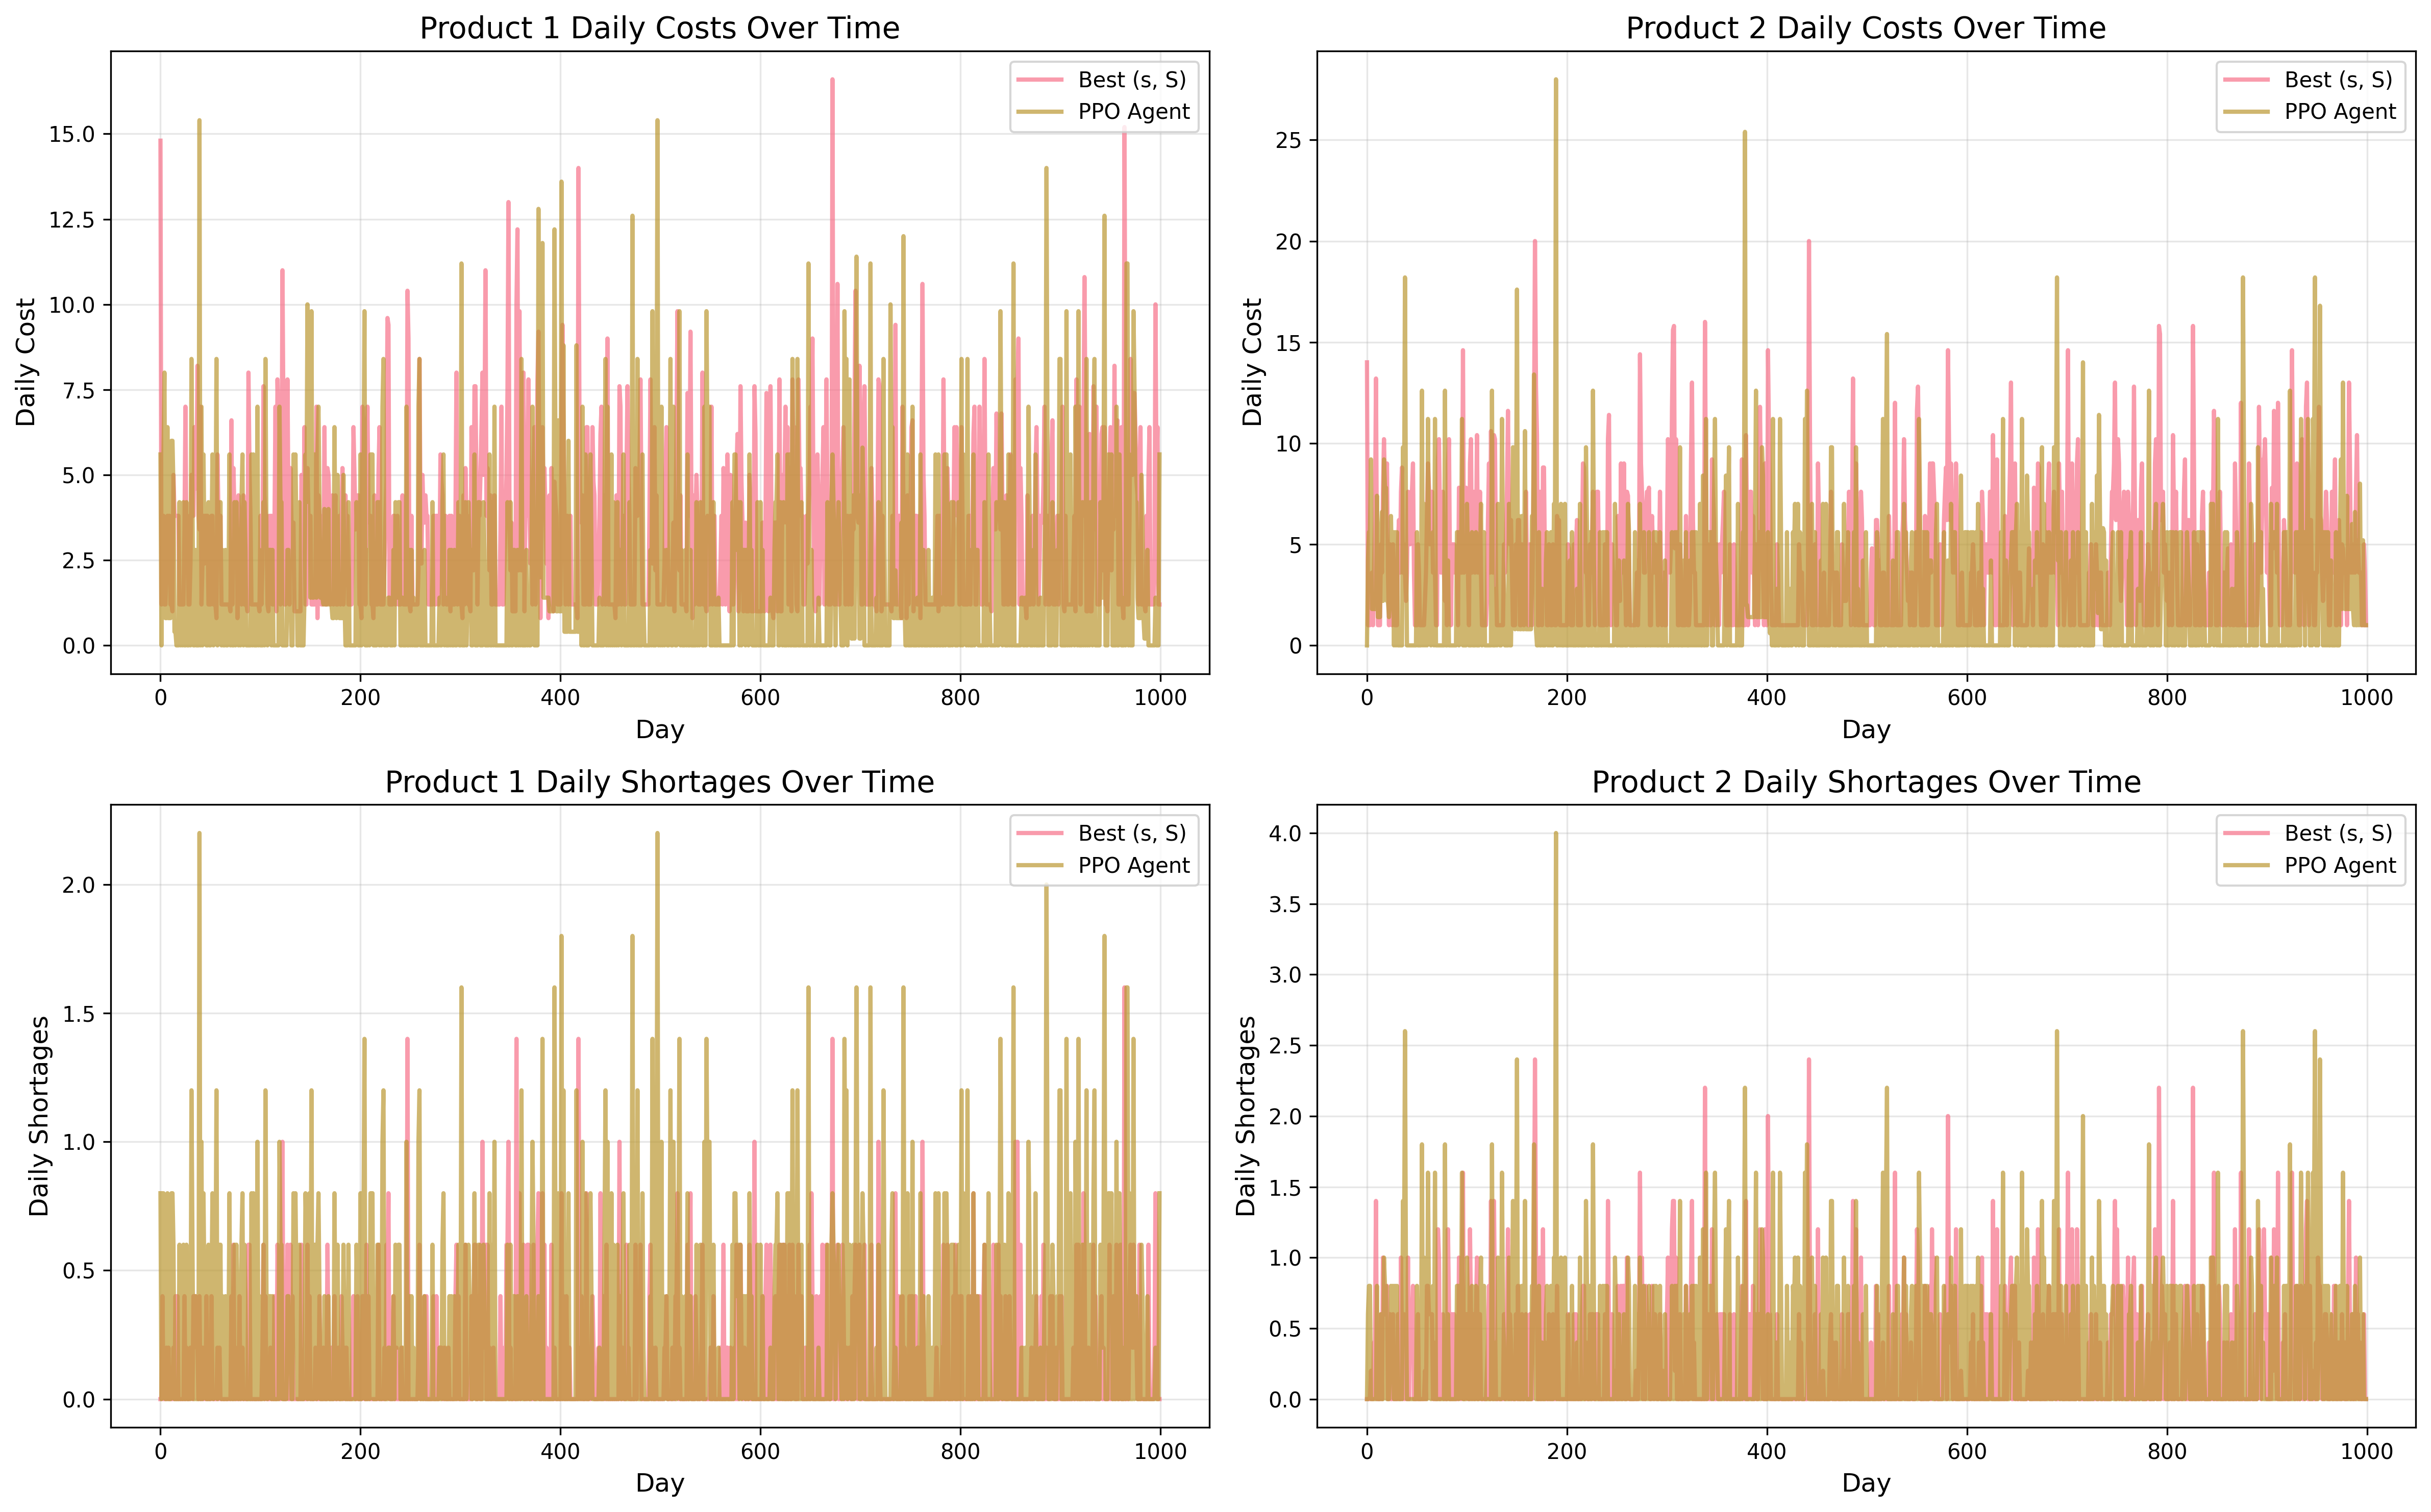

In [46]:
if os.path.exists('plots/per_product_daily_performance.png'):
    display(Image('plots/per_product_daily_performance.png'))
else:
    print("Plot not found. Run visualization cells first.")


In [47]:
print("COMPARISON TABLE:")

comparison_data = {
    'Metric': ['Avg Total Cost', 'Std Total Cost', 'Avg Service Level', 'Std Service Level'],
    '(s,S) Policy': [f'{ss_avg_cost:.2f}', f'{ss_std_cost:.2f}', f'{ss_avg_service:.2f}%', f'{ss_std_service:.2f}%'],
    'RL Agent (PPO)': [f'{rl_avg_cost:.2f}', f'{rl_std_cost:.2f}', f'{rl_avg_service:.2f}%', f'{rl_std_service:.2f}%']
}
comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

# Stability Analysis
print("STABILITY ANALYSIS (Coefficient of Variation):")
ss_cv = (ss_std_cost / ss_avg_cost) * 100
rl_cv = (rl_std_cost / rl_avg_cost) * 100
print(f"  (s,S) Policy CV: {ss_cv:.2f}%  {'STABLE' if ss_cv < 10 else 'VARIABLE'}")
print(f"  RL Agent CV:     {rl_cv:.2f}%  {'STABLE' if rl_cv < 10 else ' VARIABLE'}")

print("CONCLUSION:")

if rl_avg_cost < ss_avg_cost:
    improvement = ((ss_avg_cost - rl_avg_cost) / ss_avg_cost) * 100
    print(f"RL Agent achieves {improvement:.1f}% LOWER average cost")
    print(f" RL Agent is BETTER for cost minimization")
else:
    improvement = ((rl_avg_cost - ss_avg_cost) / rl_avg_cost) * 100
    print(f"(s,S) Policy achieves {improvement:.1f}% LOWER average cost")
    print(f"(s,S) Policy is BETTER for cost minimization")

if rl_avg_service > ss_avg_service:
    print(f"RL Agent has {rl_avg_service - ss_avg_service:.1f}% HIGHER service level")
else:
    print(f" (s,S) Policy has {ss_avg_service - rl_avg_service:.1f}% HIGHER service level")

if rl_cv < ss_cv:
    print(f"RL Agent is MORE STABLE (lower variance across seeds)")
else:
    print(f"(s,S) Policy is MORE STABLE (lower variance across seeds)")



COMPARISON TABLE:
           Metric (s,S) Policy RL Agent (PPO)
   Avg Total Cost      7305.00        4587.20
   Std Total Cost       376.45         194.62
Avg Service Level       83.70%         81.52%
Std Service Level        1.64%          1.45%
STABILITY ANALYSIS (Coefficient of Variation):
  (s,S) Policy CV: 5.15%  STABLE
  RL Agent CV:     4.24%  STABLE
CONCLUSION:
RL Agent achieves 37.2% LOWER average cost
 RL Agent is BETTER for cost minimization
 (s,S) Policy has 2.2% HIGHER service level
RL Agent is MORE STABLE (lower variance across seeds)
